### 전처리 및 EDA 코드

#### 데이터 전처리 코드

In [2]:
# build_kbo_features.py
# -*- coding: utf-8 -*-
"""
KBO 피처셋(지정 컬럼명) 생성 스크립트 (2018~2025)
- 입력: kbo_team_batting_YYYY.csv, kbo_pitcher_stats_YYYY.csv, kbo_defense_stats_YYYY.csv
- 출력: kbo_features_clean_2018_2025.csv
- 최근 10경기 승률 / 팀 WAR / 수비 WAR 또는 UZR 은 원본 32개 CSV로 계산 불가 → NaN으로 둡니다.
"""

import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path

# ========================
# 설정
# ========================
# 이 경로를 네 CSV들이 있는 폴더로 바꿔줘 (예: r"C:\Users\HongGisang\Desktop\kbo_data")
DATA_DIR = Path(r"C:/Users/HongGisang/Desktop/KBO공모전")  # <- 여기를 네 로컬 경로로!
OUT_CSV  = DATA_DIR / "kbo_features_clean_2018_2025.csv"
YEARS    = range(2018, 2026)

# 합계/이상치 팀명 제거 규칙
# (숫자 포함된 팀명, '합계', '리그합계' 등의 합산행 제거)
def is_valid_team_name(s: str) -> bool:
    if not isinstance(s, str):
        return False
    s = s.strip()
    if s in {"합계", "리그합계"}:
        return False
    if any(ch.isdigit() for ch in s):  # 예: '720'
        return False
    return len(s) > 0

def safe_div(n, d):
    n = np.asarray(n, dtype=float)
    d = np.asarray(d, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        out = n / d
        out[np.isinf(out)] = np.nan
    return out

def build_clean_features_for_year(year: int) -> pd.DataFrame:
    """연도별 지정 컬럼명 피처셋 생성"""
    try:
        bat = pd.read_csv(DATA_DIR / f"kbo_team_batting_{year}.csv")
        pit = pd.read_csv(DATA_DIR / f"kbo_pitcher_stats_{year}.csv")
        defe = pd.read_csv(DATA_DIR / f"kbo_defense_stats_{year}.csv")
    except Exception as e:
        print(f"[WARN] {year} 파일 로드 실패: {e}")
        return pd.DataFrame()

    # 팀명 정리 및 합산행 제거
    for df in (bat, pit, defe):
        if "팀명" not in df.columns:
            print(f"[WARN] {year} 데이터에 '팀명' 컬럼이 없습니다.")
            return pd.DataFrame()
        df["팀명"] = df["팀명"].astype(str).str.strip()
    bat = bat[bat["팀명"].map(is_valid_team_name)]
    pit = pit[pit["팀명"].map(is_valid_team_name)]
    defe = defe[defe["팀명"].map(is_valid_team_name)]

    # --- 3. 수비/주루 (요청 컬럼명 그대로) ---
    need_cols_def = {"팀명","G","E","DP","CS%"}
    if not need_cols_def.issubset(defe.columns):
        missing = need_cols_def - set(defe.columns)
        print(f"[WARN] {year} 수비 데이터에 필요한 컬럼이 없습니다: {missing}")
        return pd.DataFrame()

    df = defe[["팀명","G","E","DP","CS%"]].copy()
    df["팀 실책수(E, 경기당 에러율)"] = safe_div(df["E"], df["G"])
    df["수비 WAR 혹은 UZR(팀 합산)"] = np.nan  # 원본 32개 CSV로 계산 불가 → placeholder
    df["더블플레이 성공률(DP%)"] = safe_div(df["DP"], df["G"])  # DP% 원자료 부재 → DP/G 근사
    df["도루 저지율(CS%)"] = df["CS%"]

    # --- 4. 팀 밸런스 ---
    # 득점 R: 타격 테이블, 실점 RA & W/L: 투수 테이블
    need_cols_bat = {"팀명","R"}
    need_cols_pit = {"팀명","R","W","L"}
    if not need_cols_bat.issubset(bat.columns) or not need_cols_pit.issubset(pit.columns):
        print(f"[WARN] {year} 타격/투수 데이터에 필요한 컬럼이 없습니다.")
        return pd.DataFrame()

    bat_vars = bat[["팀명","R"]].copy()
    pit_vars = pit[["팀명","R","W","L"]].copy().rename(columns={"R":"RA"})

    merged = bat_vars.merge(pit_vars, on="팀명", how="inner")

    R  = merged["R"].astype(float)
    RA = merged["RA"].astype(float)
    W  = merged["W"].astype(float)
    L  = merged["L"].astype(float)

    merged["승률(Win%)"] = safe_div(W, (W + L))
    merged["Pythagorean 기대 승률"] = safe_div(R**2, (R**2 + RA**2))
    merged["팀 WAR(투수+타자 합산)"] = np.nan            # 원본으로 계산 불가 → placeholder
    merged["최근 10경기 승률"] = np.nan                  # 게임로그 부재 → placeholder

    # 병합 (지정 컬럼명만 유지)
    out = df.merge(
        merged[["팀명","승률(Win%)","Pythagorean 기대 승률","팀 WAR(투수+타자 합산)","최근 10경기 승률"]],
        on="팀명", how="left"
    )
    out.insert(0, "연도", year)
    out = out[[
        "연도","팀명",
        "팀 실책수(E, 경기당 에러율)",
        "수비 WAR 혹은 UZR(팀 합산)",
        "더블플레이 성공률(DP%)",
        "도루 저지율(CS%)",
        "승률(Win%)",
        "Pythagorean 기대 승률",
        "팀 WAR(투수+타자 합산)",
        "최근 10경기 승률",
    ]].reset_index(drop=True)

    return out

def main() -> int:
    frames = []
    for y in YEARS:
        dfy = build_clean_features_for_year(y)
        if dfy.empty:
            print(f"[INFO] {y} 시즌 데이터가 비어있어 건너뜁니다.")
            continue
        frames.append(dfy)

    if not frames:
        print("[ERROR] 생성 가능한 시즌 데이터가 없습니다.")
        return 1

    final_feats = pd.concat(frames, ignore_index=True)

    # 팀명 정리(추가 안전장치): 다시 한 번 합산행/숫자 팀명 제거
    final_feats = final_feats[final_feats["팀명"].map(is_valid_team_name)].reset_index(drop=True)

    # 저장
    OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    final_feats.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
    print(f"[OK] 저장 완료: {OUT_CSV}")
    print(final_feats.head(12).to_string(index=False))
    return 0

if __name__ == "__main__":
    main() 



[OK] 저장 완료: C:\Users\HongGisang\Desktop\KBO공모전\kbo_features_clean_2018_2025.csv
  연도  팀명  팀 실책수(E, 경기당 에러율)  수비 WAR 혹은 UZR(팀 합산)  더블플레이 성공률(DP%)  도루 저지율(CS%)  승률(Win%)  Pythagorean 기대 승률  팀 WAR(투수+타자 합산)  최근 10경기 승률
2018  두산           0.534722                  NaN        1.020833         38.7  0.645833           0.609252              NaN         NaN
2018  삼성           0.548611                  NaN        0.923611         27.5  0.485714           0.483528              NaN         NaN
2018  롯데           0.812500                  NaN        0.916667         28.9  0.478873           0.485006              NaN         NaN
2018  넥센           0.736111                  NaN        1.020833         35.8  0.520833           0.528015              NaN         NaN
2018  SK           0.805556                  NaN        0.923611         29.1  0.545455           0.563922              NaN         NaN
2018  KT           0.687500                  NaN        1.118056         29.8  0.418440           0.4517

In [1]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")
    

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


### 지표별 데이터 통합 (연도 기준)

In [3]:
import pandas as pd
import glob
import os

# ========================
# 0. 경로 설정
# ========================

# 연도별 폴더들이 들어 있는 상위 폴더 경로
DATA_DIR = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\kbo data"

# 저장 경로도 동일하게 지정
SAVE_DIR = DATA_DIR

# ========================
# 1. 통합 함수 (하위 폴더 탐색)
# ========================
def merge_csv(file_prefix, save_name):
    files = sorted(glob.glob(os.path.join(DATA_DIR, "*", f"{file_prefix}_*.csv")))
    print(f"[검색된 파일] {files}")  # 디버깅용 출력

    if not files:
        print(f"[경고] {file_prefix}_*.csv 파일이 없습니다.")
        return

    df_list = []
    for f in files:
        year = os.path.basename(f).split("_")[-1].split(".")[0]
        df = pd.read_csv(f)
        df["season"] = int(year)  # 시즌 연도 추가
        df_list.append(df)
        print(f"[불러옴] {f} → {df.shape}")

    merged_df = pd.concat(df_list, ignore_index=True)
    merged_path = os.path.join(SAVE_DIR, save_name)
    merged_df.to_csv(merged_path, index=False, encoding="utf-8-sig")
    print(f"[저장 완료] {merged_path} → {merged_df.shape}")

# ========================
# 2. 실행
# ========================
merge_csv("batting", "batting_all.csv")
merge_csv("pitching", "pitching_all.csv")
merge_csv("team_bat", "team_bat_all.csv")
merge_csv("team_pitch", "team_pitch_all.csv")


[검색된 파일] ['C:\\Users\\THKIM\\Desktop\\3학년 여름방학 프로젝트\\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\\data\\kbo data\\2018\\batting_2018.csv', 'C:\\Users\\THKIM\\Desktop\\3학년 여름방학 프로젝트\\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\\data\\kbo data\\2019\\batting_2019.csv', 'C:\\Users\\THKIM\\Desktop\\3학년 여름방학 프로젝트\\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\\data\\kbo data\\2020\\batting_2020.csv', 'C:\\Users\\THKIM\\Desktop\\3학년 여름방학 프로젝트\\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\\data\\kbo data\\2021\\batting_2021.csv', 'C:\\Users\\THKIM\\Desktop\\3학년 여름방학 프로젝트\\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\\data\\kbo data\\2022\\batting_2022.csv', 'C:\\Users\\THKIM\\Desktop\\3학년 여름방학 프로젝트\\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\\data\\kbo data\\2023\\batting_2023.csv', 'C:\\Users\\THKIM\\Desktop\\3학년 여름방학 프로젝트\\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\\data\\kbo data\\2024\\batting_2024.csv', 'C:\\Users\\THKIM\\Desktop\\3학년 여름방학 프로젝트\\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\\data\\kbo data\\2025\\batting_2025.csv']
[불러옴] C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오

### 컬럼명 한글로 변경

In [4]:
import pandas as pd

# ✅ 경로 설정
DATA_DIR = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\kbo data"

# ✅ 검증할 CSV 목록
files = {
    "batting": "batting_all.csv",
    "pitching": "pitching_all.csv",
    "team_bat": "team_bat_all.csv",
    "team_pitch": "team_pitch_all.csv"
}

# ✅ 특정 경기와 선수(수동 검증용, Statiz 예시)
check_game_id = 20180001
check_player = "박해민"  # batting/pitching에서만 적용 가능

for key, fname in files.items():
    path = f"{DATA_DIR}\\{fname}"
    df = pd.read_csv(path)
    print(f"\n=== ✅ [{key}] {fname} ===")
    print(f"총 행 수: {df.shape[0]}, 총 열 수: {df.shape[1]}")
    
    # ✅ 범위/기본 통계 확인
    numeric_cols = df.select_dtypes(include=['number']).columns
    print("\n[숫자 열 기본 통계]")
    print(df[numeric_cols].describe().T)

    # ✅ 특정 경기+선수 직접 확인 (batting/pitching만)
    if key in ["batting", "pitching"]:
        if key == "batting":
            # 이름 컬럼이 5번째(인덱스 5)에 있는 경우 → CSV 확인 후 수정 가능
            sample = df[(df.iloc[:,0] == check_game_id) & (df.iloc[:,5] == check_player)]
        else:
            sample = df[df.iloc[:,0] == check_game_id]  # 투수는 이름 비교 없이 경기만 확인
        print(f"\n[직접 검증: {check_game_id} 경기 | {check_player}]")
        print(sample)



=== ✅ [batting] batting_all.csv ===
총 행 수: 138393, 총 열 수: 27

[숫자 열 기본 통계]
           count          mean           std           min           25%  \
0       138393.0  2.021350e+07  21785.168428  2.018000e+07  2.019078e+07   
4       138393.0  5.028614e+00      3.576164  0.000000e+00  2.000000e+00   
7       138393.0  3.097454e+00      1.700242  0.000000e+00  1.000000e+00   
8       138393.0  2.718533e+00      1.583041  0.000000e+00  1.000000e+00   
9       138393.0  3.884445e-01      0.642168  0.000000e+00  0.000000e+00   
10      138393.0  7.300875e-01      0.884296  0.000000e+00  0.000000e+00   
11      138393.0  6.806703e-02      0.266336  0.000000e+00  0.000000e+00   
12      138393.0  3.660879e-01      0.775498  0.000000e+00  0.000000e+00   
13      138393.0  2.823915e-01      0.549009  0.000000e+00  0.000000e+00   
14      138393.0  4.158447e-02      0.206015  0.000000e+00  0.000000e+00   
15      138393.0  5.659318e-01      0.749022  0.000000e+00  0.000000e+00   
16      1383

In [7]:
import pandas as pd
import os

# ✅ 경로 설정
DATA_DIR = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\kbo data"

# ✅ 컬럼명 매핑
batting_rename = {
    "0": "경기ID", "1": "날짜", "2": "홈/원정", "3": "팀명", "4": "타순",
    "5": "이름", "6": "포지션", "7": "타석(PA)", "8": "타수(AB)", "9": "득점(R)",
    "10": "안타(H)", "11": "홈런(HR)", "12": "타점(RBI)", "13": "볼넷(BB)", "14": "사구(HBP)",
    "15": "삼진(SO)", "16": "땅볼(GO)", "17": "뜬공(FO)", "18": "투구수(NP)",
    "19": "병살타(GDP)", "20": "잔루(LOB)", "21": "타율(AVG)", "22": "OPS",
    "23": "LI", "24": "WPA", "25": "RE24", "season": "시즌"
}

pitching_rename = {
    "0": "경기ID", "1": "날짜", "2": "홈/원정", "3": "팀명", "4": "등판순서",
    "5": "투수이름", "6": "이닝(IP)", "7": "상대한타자수(TBF)", "8": "피안타(H)", "9": "실점(R)",
    "10": "자책점(ER)", "11": "볼넷(BB)", "12": "사구(HBP)", "13": "삼진(K)", "14": "홈런(HR)",
    "15": "땅볼-뜬공(GO-FO)", "16": "투구수-스트라이크(NP-S)", "17": "잔루계승(IR-IS)",
    "18": "게임점수(GSC)", "19": "ERA", "20": "WHIP", "21": "LI", "22": "WPA",
    "23": "RE24", "season": "시즌"
}

team_bat_rename = {
    "0": "경기ID", "1": "날짜", "2": "홈/원정", "3": "팀명", "4": "타석(PA)",
    "5": "타수(AB)", "6": "득점(R)", "7": "안타(H)", "8": "홈런(HR)", "9": "타점(RBI)",
    "10": "볼넷(BB)", "11": "사구(HBP)", "12": "삼진(SO)", "13": "땅볼(GO)", "14": "뜬공(FO)",
    "15": "투구수(NP)", "16": "병살타(GDP)", "17": "잔루(LOB)", "18": "타율(AVG)",
    "19": "OPS", "20": "LI", "21": "WPA", "22": "RE24", "season": "시즌"
}

team_pitch_rename = {
    "0": "경기ID", "1": "날짜", "2": "홈/원정", "3": "팀명", "4": "이닝(IP)",
    "5": "상대한타자수(TBF)", "6": "피안타(H)", "7": "실점(R)", "8": "자책점(ER)", "9": "볼넷(BB)",
    "10": "사구(HBP)", "11": "삼진(K)", "12": "홈런(HR)", "13": "땅볼-뜬공(GO-FO)",
    "14": "투구수-스트라이크(NP-S)", "15": "잔루계승(IR-IS)", "16": "게임점수(GSC)",
    "17": "ERA", "18": "WHIP", "19": "LI", "20": "WPA", "21": "RE24", "season": "시즌"
}

rename_map = {
    "batting_all.csv": batting_rename,
    "pitching_all.csv": pitching_rename,
    "team_bat_all.csv": team_bat_rename,
    "team_pitch_all.csv": team_pitch_rename
}

# ✅ 한글 컬럼명 덮어쓰기
for file_name, rename_dict in rename_map.items():
    path = os.path.join(DATA_DIR, file_name)
    df = pd.read_csv(path)
    
    # 컬럼명 매핑 적용
    df.rename(columns=rename_dict, inplace=True)
    
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"[완료] {file_name} → 한글화 완료, 총 열 수: {df.shape[1]}")


[완료] batting_all.csv → 한글화 완료, 총 열 수: 27
[완료] pitching_all.csv → 한글화 완료, 총 열 수: 25
[완료] team_bat_all.csv → 한글화 완료, 총 열 수: 25
[완료] team_pitch_all.csv → 한글화 완료, 총 열 수: 24


### 추가 변환

In [8]:
import pandas as pd
import os

# === ✅ 1. 경로 설정 ===
DATA_DIR = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\kbo data"

# === ✅ 2. 컬럼명 매핑(스탯티즈 기준 한글화) ===
COLUMN_MAP = {
    # 공통 기본 컬럼
    "경기ID": "경기ID", "날짜": "날짜", "홈/원정": "홈/원정", "팀명": "팀명",

    # 타격 관련
    "PA": "타석", "AB": "타수", "R": "득점", "H": "안타", "HR": "홈런",
    "RBI": "타점", "BB": "볼넷", "HBP": "사구", "SO": "삼진", "GO": "땅볼",
    "FO": "뜬공", "NP": "투구수", "GDP": "병살타", "LOB": "잔루",
    "AVG": "타율", "OPS": "OPS(출루율+장타율)", "LI": "LI(상황레버리지)",
    "WPA": "WPA(승리확률기여도)", "RE24": "RE24(득점기대기여)",

    # 투수 관련
    "IP": "이닝", "TBF": "상대한타자수", "ER": "자책점", "BB": "볼넷", 
    "H": "피안타", "K": "삼진", "WHIP": "WHIP", "ERA": "평균자책점",
}

# === ✅ 3. 마지막 컬럼 자동 제거 + 컬럼 한글화 함수 ===
def clean_and_save_csv(filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, encoding="utf-8-sig")

    print(f"\n=== ✅ [처리 전] {filename} ===")
    print(f"총 컬럼: {len(df.columns)} → {list(df.columns)}")

    # 1) 마지막 1~2개 컬럼이 불필요한 숫자형인지 체크 후 제거
    drop_cols = []
    for col in df.columns[-2:]:
        if col not in COLUMN_MAP.keys() and "시즌" not in col:
            drop_cols.append(col)
    df = df.drop(columns=drop_cols, errors="ignore")

    # 2) 컬럼명 한글화 (매핑이 없으면 기존 그대로 유지)
    df = df.rename(columns=lambda x: COLUMN_MAP.get(x, x))

    # 3) 저장
    save_name = filename.replace(".csv", "_정리완료.csv")
    save_path = os.path.join(DATA_DIR, save_name)
    df.to_csv(save_path, index=False, encoding="utf-8-sig")

    print(f"=== ✅ [처리 후] {save_name} 저장 완료 ===")
    print(f"총 컬럼: {len(df.columns)} → {list(df.columns)}")

# === ✅ 4. 실행 ===
for f in ["batting_all.csv", "pitching_all.csv", "team_bat_all.csv", "team_pitch_all.csv"]:
    clean_and_save_csv(f)



=== ✅ [처리 전] batting_all.csv ===
총 컬럼: 27 → ['경기ID', '날짜', '홈/원정', '팀명', '타순', '이름', '포지션', '타석(PA)', '타수(AB)', '득점(R)', '안타(H)', '홈런(HR)', '타점(RBI)', '볼넷(BB)', '사구(HBP)', '삼진(SO)', '땅볼(GO)', '뜬공(FO)', '투구수(NP)', '병살타(GDP)', '잔루(LOB)', '타율(AVG)', 'OPS', 'LI', 'WPA', 'RE24', '시즌']
=== ✅ [처리 후] batting_all_정리완료.csv 저장 완료 ===
총 컬럼: 27 → ['경기ID', '날짜', '홈/원정', '팀명', '타순', '이름', '포지션', '타석(PA)', '타수(AB)', '득점(R)', '안타(H)', '홈런(HR)', '타점(RBI)', '볼넷(BB)', '사구(HBP)', '삼진(SO)', '땅볼(GO)', '뜬공(FO)', '투구수(NP)', '병살타(GDP)', '잔루(LOB)', '타율(AVG)', 'OPS(출루율+장타율)', 'LI(상황레버리지)', 'WPA(승리확률기여도)', 'RE24(득점기대기여)', '시즌']

=== ✅ [처리 전] pitching_all.csv ===
총 컬럼: 25 → ['경기ID', '날짜', '홈/원정', '팀명', '등판순서', '투수이름', '이닝(IP)', '상대한타자수(TBF)', '피안타(H)', '실점(R)', '자책점(ER)', '볼넷(BB)', '사구(HBP)', '삼진(K)', '홈런(HR)', '땅볼-뜬공(GO-FO)', '투구수-스트라이크(NP-S)', '잔루계승(IR-IS)', '게임점수(GSC)', 'ERA', 'WHIP', 'LI', 'WPA', 'RE24', '시즌']
=== ✅ [처리 후] pitching_all_정리완료.csv 저장 완료 ===
총 컬럼: 25 → ['경기ID', '날짜', '홈/원정', '팀명', '등판순서', '투수이름', 

### 데이터 정제

In [11]:
import pandas as pd
import os

# === ✅ 1. 경로 설정 ===
DATA_DIR = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\kbo data"
SAVE_DIR = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
os.makedirs(SAVE_DIR, exist_ok=True)

# === ✅ 2. CSV 불러오기 ===
team_bat = pd.read_csv(os.path.join(DATA_DIR, "team_bat_all_정리완료.csv"))
team_pitch = pd.read_csv(os.path.join(DATA_DIR, "team_pitch_all_정리완료.csv"))

# === ✅ 3. 시즌+팀 단위 요약 함수 ===
def summarize_team_season(df, group_cols, agg_dict):
    return df.groupby(group_cols).agg(agg_dict).reset_index()

# === ✅ 4. 팀 타격 요약 (5번) ===
team_bat_summary = summarize_team_season(
    team_bat,
    ["시즌", "팀명"],
    {
        "득점(R)": "sum",
        "안타(H)": "sum",
        "홈런(HR)": "sum",
        "타점(RBI)": "sum",
        "타율(AVG)": "mean",
        "OPS(출루율+장타율)": "mean",
        "WPA(승리확률기여도)": "sum",
        "RE24(득점기대기여)": "sum"
    }
)

# === ✅ 5. 팀 투구 요약 (5번) ===
team_pitch_summary = summarize_team_season(
    team_pitch,
    ["시즌", "팀명"],
    {
        "이닝(IP)": "sum",
        "실점(R)": "sum",
        "자책점(ER)": "sum",
        "피안타(H)": "sum",
        "평균자책점": "mean",
        "WHIP": "mean",
        "WPA(승리확률기여도)": "sum",
        "RE24(득점기대기여)": "sum"
    }
)

# === ✅ 6. 파생 변수 생성 (6번) ===
# ▶ OPS+
league_ops = team_bat_summary.groupby("시즌")["OPS(출루율+장타율)"].transform("mean")
team_bat_summary["OPS+"] = (team_bat_summary["OPS(출루율+장타율)"] / league_ops * 100).round(1)

# ▶ ERA+ (ERA 낮을수록 좋음)
league_era = team_pitch_summary.groupby("시즌")["평균자책점"].transform("mean")
team_pitch_summary["ERA+"] = (league_era / team_pitch_summary["평균자책점"] * 100).round(1)

# ▶ WPA+, RE24+
team_bat_summary["WPA+"] = (
    team_bat_summary["WPA(승리확률기여도)"] /
    team_bat_summary.groupby("시즌")["WPA(승리확률기여도)"].transform("mean") * 100
).round(1)

team_bat_summary["RE24+"] = (
    team_bat_summary["RE24(득점기대기여)"] /
    team_bat_summary.groupby("시즌")["RE24(득점기대기여)"].transform("mean") * 100
).round(1)

team_pitch_summary["WPA+"] = (
    team_pitch_summary["WPA(승리확률기여도)"] /
    team_pitch_summary.groupby("시즌")["WPA(승리확률기여도)"].transform("mean") * 100
).round(1)

team_pitch_summary["RE24+"] = (
    team_pitch_summary["RE24(득점기대기여)"] /
    team_pitch_summary.groupby("시즌")["RE24(득점기대기여)"].transform("mean") * 100
).round(1)

# === ✅ 7. 저장 ===
bat_save = os.path.join(SAVE_DIR, "team_bat_summary_파생완료.csv")
pitch_save = os.path.join(SAVE_DIR, "team_pitch_summary_파생완료.csv")

team_bat_summary.to_csv(bat_save, index=False, encoding="utf-8-sig")
team_pitch_summary.to_csv(pitch_save, index=False, encoding="utf-8-sig")

print("✅ [저장 완료]")
print(f"타격 요약+파생: {bat_save} → {team_bat_summary.shape}")
print(f"투구 요약+파생: {pitch_save} → {team_pitch_summary.shape}")


✅ [저장 완료]
타격 요약+파생: C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\team_bat_summary_파생완료.csv → (80, 13)
투구 요약+파생: C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\team_pitch_summary_파생완료.csv → (80, 13)


### 5. 상황·컨텍스트 변수
### 6. 추가 고급 변수

In [29]:
import pandas as pd
import numpy as np
from functools import reduce

# ===========================
# 1. 데이터 로드
# ===========================
DATA_DIR = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\kbo data"
SAVE_DIR = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"

batting_all = pd.read_csv(f"{DATA_DIR}/batting_all_정리완료.csv")
team_bat_all = pd.read_csv(f"{DATA_DIR}/team_bat_all_정리완료.csv")
team_pitch_all = pd.read_csv(f"{DATA_DIR}/team_pitch_all_정리완료.csv")

# ===========================
# 2. 함수 정의
# ===========================

# ✅ 1) 홈/원정 승률
def calc_home_away_win(df):
    df = df.copy()

    # "상대실점" 계산 (각 경기에서 팀이 득점한 점수 기준으로 상대 실점 = 팀 실점)
    if "상대실점" not in df.columns:
        df["상대실점"] = df.groupby(["경기ID", "날짜"])["득점(R)"].transform(lambda x: x[::-1].values)

    return (
        df.groupby(["시즌", "팀명", "홈/원정"])
        .apply(lambda x: (x["득점(R)"] > x["상대실점"]).sum() / len(x))
        .reset_index(name="승률")
        .pivot(index=["시즌", "팀명"], columns="홈/원정", values="승률")
        .fillna(0)
        .rename(columns={"home": "홈승률", "away": "원정승률"})
        .reset_index()
    )

# ✅ 2) 연속경기 및 휴식일수
def calc_consecutive_and_rest(df):
    df = df.copy()
    df["날짜"] = pd.to_datetime(df["날짜"])
    df = df.sort_values(["팀명", "날짜"])
    df["이전날짜"] = df.groupby("팀명")["날짜"].shift(1)
    df["휴식일"] = (df["날짜"] - df["이전날짜"]).dt.days.fillna(0).astype(int)
    
    # ✅ transform으로 오류 해결
    df["연속경기"] = df.groupby("팀명")["휴식일"].transform(lambda x: (x == 1).cumsum())

    summary = (
        df.groupby(["시즌", "팀명"])
        .agg({"연속경기": "max", "휴식일": "mean"})
        .reset_index()
        .rename(columns={"휴식일": "휴식일수"})
    )
    return summary

# ✅ 3) 구장 OPS, ERA (홈구장 기준)
def calc_park_factors(team_bat, team_pitch):
    bat = (
        team_bat.groupby(["시즌", "팀명"])
        .agg({"OPS(출루율+장타율)": "mean"})
        .reset_index()
        .rename(columns={"OPS(출루율+장타율)": "구장OPS"})
    )
    pit = (
        team_pitch.groupby(["시즌", "팀명"])
        .agg({"평균자책점": "mean"})
        .reset_index()
        .rename(columns={"평균자책점": "구장ERA"})
    )
    return pd.merge(bat, pit, on=["시즌", "팀명"], how="left")

# ✅ 4) WPA / RE24 합산
def calc_wpa_re24(team_bat):
    return (
        team_bat.groupby(["시즌", "팀명"])
        .agg({"WPA(승리확률기여도)": "sum", "RE24(득점기대기여)": "sum"})
        .reset_index()
    )

# ✅ 5) HL 변수 (평균값)
def calc_home_away_hl(batting):
    return (
        batting.groupby(["시즌", "팀명"])
        .agg({
            "WPA(승리확률기여도)": "mean",
            "타율(AVG)": "mean",
            "OPS(출루율+장타율)": "mean"
        })
        .reset_index()
        .rename(columns={
            "WPA(승리확률기여도)": "HL_WPA",
            "타율(AVG)": "HL_타율",
            "OPS(출루율+장타율)": "HL_OPS"
        })
    )

# ✅ 6) 병합 함수
def merge_all(*dfs):
    return reduce(lambda left, right: pd.merge(left, right, on=["시즌", "팀명"], how="outer"), dfs)

# ===========================
# 3. 변수 생성
# ===========================
home_away = calc_home_away_win(team_bat_all)
consecutive_rest = calc_consecutive_and_rest(team_bat_all)
park_factors = calc_park_factors(team_bat_all, team_pitch_all)
wpa_re24 = calc_wpa_re24(team_bat_all)
hl_vars = calc_home_away_hl(batting_all)

# 최종 병합
final_df = merge_all(home_away, consecutive_rest, park_factors, wpa_re24, hl_vars)

# ===========================
# 4. 저장
# ===========================
save_path = f"{SAVE_DIR}/team_variables_5_6.csv"
final_df.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"✅ 저장 완료 → {save_path}")
print(final_df.head(10))


✅ 저장 완료 → C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수/team_variables_5_6.csv
     시즌   팀명      원정승률       홈승률  연속경기      휴식일수     구장OPS      구장ERA  \
0  2018  KIA  0.458333  0.347222   107  1.430556  0.286438  44.138889   
1  2018   KT  0.605634  0.242857   103  1.439716  0.268270  43.985816   
2  2018   LG  0.597222  0.375000   111  1.409722  0.287021  46.937500   
3  2018   NC  0.464789  0.271429   105  1.439716  0.254794  45.127660   
4  2018   SK  0.554054  0.347222   105  1.513699  0.272007  50.404110   
5  2018   두산  0.680556  0.333333   111  1.416667  0.303618  47.979167   
6  2018   롯데  0.690141  0.291667   104  1.426573  0.284483  45.272727   
7  2018   삼성  0.666667  0.253521   103  1.450000  0.283414  44.035714   
8  2018   키움  0.613333  0.415584   114  1.453947  0.277441  48.269737   
9  2018   한화  0.581081  0.260274   111  1.448980  0.270857  45.938776   

   WPA(승리확률기여도)  RE24(득점기대기여)    HL_WPA     HL_타율    HL_OPS  
0        464.06        17

C:\Users\THKIM\AppData\Local\Temp\ipykernel_9812\715097525.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["득점(R)"] > x["상대실점"]).sum() / len(x))


### 추가 변수
### 1. 상대 전적 승률

In [31]:
import pandas as pd

# === 1. 데이터 로드 ===
DATA_DIR = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\kbo data"
team_bat_all = pd.read_csv(f"{DATA_DIR}/team_bat_all_정리완료.csv")

# === 2. 상대팀과 실점 컬럼 생성 ===
# 같은 경기ID 내에서 팀별 상대팀과 상대팀 득점(R)을 매핑
opponent_df = (
    team_bat_all[["경기ID", "팀명", "득점(R)"]]
    .rename(columns={"팀명": "상대팀", "득점(R)": "상대득점"})
)

team_bat_all = pd.merge(
    team_bat_all,
    opponent_df,
    on="경기ID",
    how="left"
)

# 자기 자신의 팀과 같은 행 제거 → 상대팀의 득점만 남기기
team_bat_all = team_bat_all[team_bat_all["팀명"] != team_bat_all["상대팀"]]

# === 3. 승리여부 계산 ===
team_bat_all["승리여부"] = team_bat_all["득점(R)"] > team_bat_all["상대득점"]

# === 4. 상대 전적 승률 계산 ===
opponent_winrate = (
    team_bat_all.groupby(["시즌", "팀명", "상대팀"])["승리여부"]
    .mean()
    .reset_index()
    .rename(columns={"승리여부": "상대승률"})
)

# === 5. 시즌별 평균 상대승률 (주요 상대팀 요약)
opponent_avg_winrate = (
    opponent_winrate.groupby(["시즌", "팀명"])["상대승률"]
    .mean()
    .reset_index()
)

# === 6. 저장 ===
SAVE_DIR = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
opponent_avg_winrate.to_csv(f"{SAVE_DIR}/team_상대승률.csv", index=False, encoding="utf-8-sig")

print("✅ 상대 전적 승률 계산 및 저장 완료!")
print(opponent_avg_winrate.head())


✅ 상대 전적 승률 계산 및 저장 완료!
     시즌   팀명      상대승률
0  2018  KIA  0.404385
1  2018   KT  0.425926
2  2018   LG  0.486111
3  2018   NC  0.371759
4  2018   SK  0.451706


### 2. 선수 나이 / 팀 평균나이

In [5]:
import pandas as pd
import re
from datetime import datetime

# ✅ 1. 복붙한 텍스트 (여기에 그대로 붙여넣으세요)
raw_text = """
한화 이글스 선수등록명단
등번호	감독	투타유형	생년월일	체격
74	김경문	우투우타	1958-11-01	178cm, 80kg
등번호	코치	투타유형	생년월일	체격
76	윤규진	우투우타	1984-07-28	187cm, 91kg
79	양상문	좌투좌타	1961-03-24	174cm, 79kg
80	고동진	좌투좌타	1980-04-01	183cm, 85kg
82	김재걸	우투우타	1972-09-07	177cm, 70kg
83	김우석	우투우타	1975-09-02	181cm, 79kg
85	정현석	우투우타	1984-03-01	182cm, 93kg
87	김민호	좌투좌타	1961-04-28	183cm, 82kg
88	양승관	우투우타	1959-06-02	180cm, 80kg
90	김정민	우투우타	1970-03-15	184cm, 83kg
91	추승우	우투좌타	1979-09-24	187cm, 74kg
등번호	투수	투타유형	생년월일	체격
1	문동주	우투우타	2003-12-23	188cm, 97kg
11	엄상백	우언우타	1996-10-04	187cm, 72kg
26	한승혁	우투좌타	1993-01-03	185cm, 100kg
29	황준서	좌투좌타	2005-08-22	185cm, 78kg
30	폰세	우투우타	1994-04-25	198cm, 115kg
38	김종수	우투우타	1994-06-03	180cm, 88kg
43	정우주	우투우타	2006-11-07	184cm, 88kg
44	김서현	우투우타	2004-05-31	188cm, 86kg
47	김범수	좌투좌타	1995-10-03	181cm, 92kg
55	와이스	우투우타	1996-12-10	193cm, 95kg
58	박상원	우투우타	1994-09-09	187cm, 98kg
66	주현상	우투우타	1992-08-10	177cm, 92kg
68	조동욱	좌투좌타	2004-11-02	190cm, 82kg
99	류현진	좌투우타	1987-03-25	190cm, 113kg
등번호	포수	투타유형	생년월일	체격
13	최재훈	우투우타	1989-08-27	178cm, 94kg
59	허인서	우투우타	2003-07-11	182cm, 93kg
등번호	내야수	투타유형	생년월일	체격
2	심우준	우투우타	1995-04-28	183cm, 75kg
7	이도윤	우투좌타	1996-10-07	175cm, 79kg
8	노시환	우투우타	2000-12-03	185cm, 105kg
16	하주석	우투좌타	1994-02-25	185cm, 92kg
22	채은성	우투우타	1990-02-06	186cm, 92kg
51	문현빈	우투좌타	2004-04-20	174cm, 82kg
95	황영묵	우투좌타	1999-10-16	177cm, 80kg
등번호	외야수	투타유형	생년월일	체격
0	리베라토	좌투좌타	1995-12-18	185cm, 79kg
10	이진영	우투우타	1997-07-21	183cm, 89kg
25	김태연	우투우타	1997-06-10	178cm, 96kg
41	최인호	우투좌타	2000-01-30	178cm, 82kg
50	이원석	우투우타	1999-03-31	177cm, 80kg

LG 트윈스 선수등록명단
등번호	감독	투타유형	생년월일	체격
85	염경엽	우투우타	1968-03-01	178cm, 65kg
등번호	코치	투타유형	생년월일	체격
73	김일경	우투우타	1978-07-01	178cm, 68kg
74	송지만	우투우타	1973-03-02	178cm, 85kg
80	박경완	우투우타	1972-07-11	178cm, 76kg
81	김정준	우투우타	1970-02-11	181cm, 84kg
83	정수성	우투좌타	1978-03-04	173cm, 72kg
93	장진용	우투우타	1986-01-28	187cm, 92kg
94	김재율	우투우타	1989-01-14	186cm, 99kg
97	모창민	우투우타	1985-05-08	188cm, 89kg
99	김광삼	우투좌타	1980-08-15	184cm, 90kg
등번호	투수	투타유형	생년월일	체격
1	임찬규	우투우타	1992-11-20	185cm, 80kg
11	함덕주	좌투좌타	1995-01-13	181cm, 78kg
13	송승기	좌투좌타	2002-04-10	181cm, 90kg
19	박시원	우투우타	2006-04-12	193cm, 93kg
29	손주영	좌투좌타	1998-12-02	191cm, 95kg
30	에르난데스	우투우타	1995-05-03	185cm, 97kg
31	이정용	우투우타	1996-03-26	185cm, 83kg
32	이지강	우투우타	1999-07-02	183cm, 85kg
42	김진성	우투우타	1985-03-07	186cm, 90kg
46	치리노스	우투우타	1993-12-26	188cm, 102kg
50	장현식	우투우타	1995-02-24	181cm, 91kg
54	유영찬	우투우타	1997-03-07	185cm, 90kg
61	백승현	우투우타	1995-05-26	183cm, 90kg
67	김영우	우투우타	2005-01-14	185cm, 90kg
등번호	포수	투타유형	생년월일	체격
26	이주헌	우투우타	2003-03-04	185cm, 92kg
27	박동원	우투우타	1990-04-07	178cm, 92kg
44	김성우	우투우타	2003-11-15	180cm, 85kg
등번호	내야수	투타유형	생년월일	체격
2	문보경	우투좌타	2000-07-19	182cm, 88kg
4	신민재	우투좌타	1996-01-21	171cm, 67kg
5	김주성	우투우타	1998-01-30	180cm, 81kg
6	구본혁	우투우타	1997-01-11	177cm, 75kg
10	오지환	우투좌타	1990-03-12	185cm, 80kg
59	천성호	우투좌타	1997-10-30	183cm, 85kg
등번호	외야수	투타유형	생년월일	체격
3	최원영	우투우타	2003-07-18	174cm, 76kg
8	문성주	좌투좌타	1997-02-20	175cm, 78kg
17	박해민	우투좌타	1990-02-24	180cm, 75kg
22	김현수	우투좌타	1988-01-12	188cm, 105kg
64	박관우	좌투좌타	2006-03-22	174cm, 82kg

롯데 자이언츠 선수등록명단
등번호	감독	투타유형	생년월일	체격
88	김태형	우투우타	1967-09-12	175cm, 82kg
등번호	코치	투타유형	생년월일	체격
70	유재신	우투우타	1987-11-21	179cm, 78kg
71	이재율	우언우타	1986-05-28	179cm, 82kg
72	김민호	우투우타	1969-03-19	181cm, 81kg
74	조원우	우투우타	1971-04-08	178cm, 82kg
80	백용환	우투우타	1989-03-20	179cm, 91kg
81	주형광	좌투좌타	1976-03-01	185cm, 92kg
84	임훈	좌투좌타	1985-07-17	186cm, 86kg
89	문규현	우투우타	1983-07-05	184cm, 96kg
90	고영민	우투우타	1984-02-08	182cm, 73kg
94	이성곤	우투좌타	1992-03-25	186cm, 104kg
등번호	투수	투타유형	생년월일	체격
19	김강현	우투좌타	1995-02-27	177cm, 84kg
21	박세웅	우투우타	1995-11-30	182cm, 85kg
23	심재민	좌투우타	1994-02-18	182cm, 92kg
32	감보아	좌투양타	1997-01-17	185cm, 92kg
34	김원중	우투좌타	1993-06-14	192cm, 96kg
36	데이비슨	좌투좌타	1996-03-25	188cm, 97kg
37	이민석	우투우타	2003-12-10	189cm, 95kg
38	홍민기	좌투좌타	2001-07-20	185cm, 85kg
43	나균안	우투우타	1998-03-16	186cm, 109kg
55	윤성빈	우투우타	1999-02-26	197cm, 90kg
56	최준용	우투우타	2001-10-10	185cm, 85kg
57	정현수	좌투좌타	2001-05-10	180cm, 84kg
65	정철원	우투우타	1999-03-27	192cm, 95kg
등번호	포수	투타유형	생년월일	체격
27	유강남	우투우타	1992-07-15	182cm, 88kg
42	정보근	우투우타	1999-08-31	175cm, 89kg
등번호	내야수	투타유형	생년월일	체격
2	고승민	우투좌타	2000-08-11	189cm, 92kg
6	한태양	우투우타	2003-09-15	181cm, 76kg
16	김민성	우투우타	1988-12-17	181cm, 94kg
30	이호준	우투좌타	2004-03-20	172cm, 72kg
33	손호영	우투우타	1994-08-23	182cm, 88kg
51	나승엽	우투좌타	2002-02-15	190cm, 82kg
53	박승욱	우투좌타	1992-12-04	184cm, 83kg
등번호	외야수	투타유형	생년월일	체격
0	황성빈	우투좌타	1997-12-19	172cm, 76kg
7	장두성	우투좌타	1999-09-16	176cm, 75kg
8	전준우	우투우타	1986-02-25	184cm, 98kg
29	레이예스	우투양타	1994-10-05	196cm, 87kg
50	김동혁	좌투좌타	2000-09-15	177cm, 77kg
91	윤동희	우투우타	2003-09-18	187cm, 85kg

KT 위즈 선수등록명단
등번호	감독	투타유형	생년월일	체격
71	이강철	우언우타	1966-05-24	180cm, 78kg
등번호	코치	투타유형	생년월일	체격
69	박경수	우투우타	1984-03-31	178cm, 80kg
72	김강	좌투좌타	1988-10-16	188cm, 92kg
75	장재중	우투우타	1971-05-19	172cm, 72kg
76	박기혁	우투우타	1981-06-04	179cm, 77kg
77	김태한	좌투좌타	1969-10-22	181cm, 87kg
81	유한준	우투우타	1981-07-01	186cm, 97kg
82	제춘모	우투우타	1982-04-05	190cm, 91kg
84	최만호	우투우타	1974-03-04	170cm, 73kg
87	전병두	좌투좌타	1984-10-14	181cm, 77kg
등번호	투수	투타유형	생년월일	체격
1	고영표	우언우타	1991-09-16	187cm, 88kg
12	우규민	우언우타	1985-01-21	184cm, 75kg
19	배제성	우투좌타	1996-09-29	190cm, 90kg
26	김민수	우투우타	1992-07-24	188cm, 80kg
30	소형준	우투우타	2001-09-16	189cm, 92kg
32	패트릭	우투우타	1995-06-10	196cm, 96kg
37	이상동	우투우타	1995-11-24	181cm, 88kg
38	주권	우투우타	1995-05-31	181cm, 82kg
41	손동현	우투우타	2001-01-23	183cm, 88kg
47	오원석	좌투좌타	2001-04-23	182cm, 80kg
60	박영현	우투우타	2003-10-11	183cm, 91kg
63	원상현	우투우타	2004-10-16	183cm, 83kg
65	헤이수스	좌투좌타	1996-12-10	192cm, 104kg
99	강건	우투우타	2004-07-12	183cm, 85kg
등번호	포수	투타유형	생년월일	체격
22	장성우	우투우타	1990-01-17	187cm, 100kg
42	조대현	우투우타	1999-08-06	183cm, 81kg
50	강백호	우투좌타	1999-07-29	184cm, 98kg
등번호	내야수	투타유형	생년월일	체격
4	오윤석	우투우타	1992-02-24	180cm, 87kg
7	김상수	우투우타	1990-03-23	175cm, 68kg
10	황재균	우투우타	1987-07-28	183cm, 96kg
13	허경민	우투우타	1990-08-26	176cm, 69kg
52	권동진	우투좌타	1998-09-12	178cm, 83kg
56	장준원	우투우타	1995-11-21	183cm, 77kg
등번호	외야수	투타유형	생년월일	체격
3	로하스	우투양타	1990-05-24	189cm, 102kg
23	안현민	우투우타	2003-08-22	183cm, 90kg
27	배정대	우투우타	1995-06-12	185cm, 80kg
33	이정훈	우투좌타	1994-12-07	185cm, 90kg
53	김민혁	우투좌타	1995-11-21	181cm, 71kg

KIA 타이거즈 선수등록명단
등번호	감독	투타유형	생년월일	체격
71	이범호	우투우타	1981-11-25	183cm, 95kg
등번호	코치	투타유형	생년월일	체격
68	손승락	우투우타	1982-03-04	187cm, 99kg
73	정재훈	우투우타	1980-01-01	178cm, 83kg
75	조재영	우투우타	1980-03-15	182cm, 87kg
76	김주찬	우투우타	1981-03-25	183cm, 95kg
77	홍세완	우투우타	1978-01-16	183cm, 85kg
81	윤해진	우투우타	1989-02-25	178cm, 84kg
83	타케시	우투우타	1967-03-17	178cm, 95kg
85	이동걸	우투우타	1983-08-12	185cm, 95kg
89	조승범	우투우타	1989-09-25	189cm, 100kg
99	김민우	우투우타	1979-03-21	184cm, 92kg
등번호	투수	투타유형	생년월일	체격
11	조상우	우투우타	1994-09-04	186cm, 97kg
20	이준영	좌투좌타	1992-08-10	177cm, 85kg
32	김현수	우투우타	2000-07-10	185cm, 90kg
39	최지민	좌투좌타	2003-09-10	185cm, 100kg
40	네일	우투우타	1993-02-08	193cm, 83kg
43	김건국	우투우타	1988-02-02	183cm, 86kg
48	이의리	좌투좌타	2002-06-16	185cm, 90kg
51	전상현	우투우타	1996-04-18	182cm, 88kg
54	양현종	좌투좌타	1988-03-01	183cm, 91kg
60	김도현	우투우타	2000-09-15	183cm, 87kg
62	정해영	우투우타	2001-08-23	189cm, 98kg
65	성영탁	우투우타	2004-07-28	180cm, 89kg
66	이도현	우투우타	2005-01-07	188cm, 90kg
69	김대유	좌투좌타	1991-05-08	187cm, 92kg
등번호	포수	투타유형	생년월일	체격
42	김태군	우투우타	1989-12-30	182cm, 92kg
55	한준수	우투좌타	1999-02-13	184cm, 95kg
등번호	내야수	투타유형	생년월일	체격
1	박찬호	우투우타	1995-06-05	178cm, 72kg
2	박민	우투우타	2001-06-05	184cm, 84kg
3	김선빈	우투우타	1989-12-18	165cm, 77kg
14	김규성	우투좌타	1997-03-08	185cm, 88kg
29	변우혁	우투우타	2000-03-18	185cm, 100kg
45	위즈덤	우투우타	1991-08-27	188cm, 99kg
56	오선우	좌투좌타	1996-12-13	186cm, 95kg
등번호	외야수	투타유형	생년월일	체격
16	최원준	우투좌타	1997-03-23	178cm, 85kg
27	김호령	우투우타	1992-04-30	178cm, 85kg
34	최형우	우투좌타	1983-12-16	180cm, 106kg
47	나성범	좌투좌타	1989-10-03	183cm, 100kg
57	고종욱	우투좌타	1989-01-11	184cm, 83kg
KIA 타이거즈 등/말소 현황
등록* 특별엔트리
등번호	선수명	포지션	투타유형	생년월일	체격
43	김건국	투수	우투우타	1988-02-02	183cm, 86kg
66	이도현	투수	우투우타	2005-01-07	188cm, 90kg
29	변우혁	내야수	우투우타	2000-03-18	185cm, 100kg
말소
* 코로나19 특별규정

등번호	선수명	포지션	투타유형	생년월일	체격
28	이형범	투수	우투우타	1994-02-27	181cm, 80kg
63	이호민	투수	우투우타	2006-08-26	182cm, 85kg
8	이창진	외야수	우투우타	1991-03-04	173cm, 85kg

삼성 라이온즈 선수등록명단
등번호	감독	투타유형	생년월일	체격
70	박진만	우투우타	1976-11-30	178cm, 82kg
등번호	코치	투타유형	생년월일	체격
74	박한이	좌투좌타	1979-01-28	182cm, 91kg
76	손주인	우투우타	1983-12-01	179cm, 82kg
81	최일언	우투우타	1961-07-27	177cm, 80kg
85	이진영	좌투좌타	1980-06-15	185cm, 90kg
87	박희수	좌투좌타	1983-07-13	184cm, 88kg
89	박석진	우언우타	1972-07-19	179cm, 80kg
92	정병곤	우투우타	1988-03-23	173cm, 73kg
93	이종욱	좌투좌타	1980-06-18	176cm, 78kg
98	채상병	우투우타	1979-12-18	184cm, 95kg
99	이마에		1983-08-26	180cm, 89kg
등번호	투수	투타유형	생년월일	체격
1	이호성	우투우타	2004-08-14	184cm, 87kg
3	최원태	우투우타	1997-01-07	184cm, 104kg
4	육선엽	우투우타	2005-07-13	190cm, 90kg
18	원태인	우투우타	2000-04-06	183cm, 92kg
20	이승현	우투우타	1991-11-20	181cm, 92kg
27	김태훈	우투우타	1992-03-02	187cm, 101kg
28	이승민	좌투좌타	2000-08-26	174cm, 79kg
42	양창섭	우투우타	1999-09-22	182cm, 85kg
44	김대호	우투우타	2001-10-15	185cm, 100kg
55	배찬승	좌투좌타	2006-01-01	180cm, 85kg
60	가라비토	우투우타	1995-08-19	183cm, 100kg
62	김재윤	우투우타	1990-09-16	185cm, 91kg
75	후라도	우투우타	1996-01-30	188cm, 109kg
등번호	포수	투타유형	생년월일	체격
2	김재성	우투좌타	1996-10-30	185cm, 85kg
47	강민호	우투우타	1985-08-18	185cm, 100kg
등번호	내야수	투타유형	생년월일	체격
0	디아즈	좌투좌타	1996-11-19	188cm, 105kg
7	이재현	우투우타	2003-02-04	180cm, 82kg
16	류지혁	우투좌타	1994-01-13	181cm, 75kg
30	김영웅	우투좌타	2003-08-24	183cm, 81kg
34	전병우	우투우타	1992-10-24	182cm, 93kg
56	이해승	우투우타	2000-08-01	180cm, 86kg
68	양도근	우투우타	2003-02-06	173cm, 72kg
등번호	외야수	투타유형	생년월일	체격
5	구자욱	우투좌타	1993-02-12	189cm, 75kg
13	이성규	우투우타	1993-08-03	178cm, 82kg
25	김태훈	우투좌타	1996-03-31	177cm, 78kg
39	김성윤	좌투좌타	1999-02-02	163cm, 62kg
63	홍현빈	우투좌타	1997-08-29	174cm, 70kg
66	박승규	우투우타	2000-09-02	178cm, 80kg

SSG 랜더스 선수등록명단
등번호	감독	투타유형	생년월일	체격
71	이숭용	좌투좌타	1971-03-10	186cm, 98kg
등번호	코치	투타유형	생년월일	체격
70	손시헌	우투우타	1980-10-19	172cm, 73kg
72	강병식	우투좌타	1977-04-23	182cm, 91kg
73	오준혁	우투좌타	1992-03-11	188cm, 95kg
74	경헌호	우투우타	1977-07-25	181cm, 95kg
82	세리자와	우투우타	1968-04-12	177cm, 80kg
84	조동화	좌투좌타	1981-03-22	175cm, 75kg
86	윤재국	좌투좌타	1975-05-05	176cm, 78kg
88	송신영	우투우타	1977-03-01	178cm, 93kg
91	이승호	좌투좌타	1981-09-09	176cm, 86kg
등번호	투수	투타유형	생년월일	체격
19	조병현	우투우타	2002-05-08	182cm, 90kg
29	김광현	좌투좌타	1988-07-22	188cm, 88kg
30	최민준	우투우타	1999-06-11	178cm, 83kg
33	앤더슨	우투우타	1994-03-22	194cm, 83kg
34	한두솔	좌투좌타	1997-01-15	177cm, 86kg
38	노경은	우투우타	1984-03-11	187cm, 100kg
41	김민	우투우타	1999-04-14	185cm, 88kg
42	문승원	우투우타	1989-11-28	180cm, 88kg
43	김택형	좌투좌타	1996-10-10	185cm, 90kg
55	화이트	우투우타	1994-12-28	190cm, 95kg
57	박시후	좌투좌타	2001-05-10	182cm, 88kg
65	전영준	우투우타	2002-04-16	190cm, 100kg
66	박기호	우투우타	2005-07-26	184cm, 80kg
92	이로운	우투우타	2004-09-11	185cm, 105kg
등번호	포수	투타유형	생년월일	체격
25	신범수	우투좌타	1998-01-25	177cm, 83kg
59	이지영	우투우타	1986-02-27	177cm, 88kg
등번호	내야수	투타유형	생년월일	체격
1	박지환	우투우타	2005-07-12	183cm, 75kg
3	정준재	우투좌타	2003-01-03	165cm, 68kg
5	김찬형	우투우타	1997-12-29	182cm, 83kg
7	최준우	우투좌타	1999-03-25	176cm, 78kg
10	안상현	우투우타	1997-01-27	178cm, 74kg
14	최정	우투우타	1987-02-28	180cm, 90kg
18	고명준	우투우타	2002-07-08	185cm, 94kg
52	석정우	우투우타	1999-01-20	180cm, 82kg
등번호	외야수	투타유형	생년월일	체격
27	에레디아	좌투우타	1991-01-31	178cm, 88kg
37	오태곤	우투우타	1991-11-18	186cm, 88kg
47	김성욱	우투우타	1993-05-01	181cm, 83kg
54	최지훈	우투좌타	1997-07-23	178cm, 82kg
SSG 랜더스 등/말소 현황
등록* 특별엔트리
등번호	선수명	포지션	투타유형	생년월일	체격
47	김성욱	외야수	우투우타	1993-05-01	181cm, 83kg
말소
* 코로나19 특별규정

등번호	선수명	포지션	투타유형	생년월일	체격
35	한유섬	외야수	우투좌타	1989-08-09	190cm, 105kg

NC 다이노스 선수등록명단
등번호	감독	투타유형	생년월일	체격
27	이호준	우투우타	1976-02-08	187cm, 95kg
등번호	코치	투타유형	생년월일	체격
70	서재응	우투우타	1977-05-24	181cm, 97kg
73	김종호	좌투좌타	1984-05-31	184cm, 83kg
75	진종길	우투좌타	1981-09-23	178cm, 80kg
76	전민수	우투좌타	1989-03-18	177cm, 76kg
79	조영훈	좌투좌타	1982-11-12	185cm, 90kg
80	지석훈	우투우타	1984-03-17	181cm, 81kg
84	박용근	우투우타	1984-01-21	172cm, 76kg
86	김종민	우투우타	1986-03-30	176cm, 85kg
90	손정욱	좌투좌타	1990-12-24	182cm, 84kg
99	이용훈	우투우타	1977-07-14	183cm, 83kg
등번호	투수	투타유형	생년월일	체격
3	라일리	우투우타	1996-07-09	190cm, 100kg
12	로건	좌투좌타	1997-05-23	186cm, 105kg
13	임정호	좌투좌타	1990-04-16	188cm, 90kg
17	김영규	좌투좌타	2000-02-10	188cm, 86kg
18	신민혁	우투우타	1999-02-04	184cm, 95kg
20	목지훈	우투우타	2004-05-11	181cm, 83kg
40	이준혁	우투우타	2003-06-30	184cm, 87kg
41	류진욱	우투우타	1996-10-10	189cm, 88kg
45	이용찬	우투우타	1989-01-02	185cm, 85kg
50	소이현	우투우타	1999-02-09	185cm, 93kg
54	김진호	우투우타	1998-06-07	183cm, 90kg
57	전사민	우투우타	1999-07-06	194cm, 85kg
61	배재환	우투우타	1995-02-24	186cm, 95kg
95	김태훈	우투우타	2006-10-26	188cm, 88kg
등번호	포수	투타유형	생년월일	체격
1	안중열	우투우타	1995-09-01	176cm, 87kg
25	김형준	우투우타	1999-11-02	187cm, 98kg
등번호	내야수	투타유형	생년월일	체격
2	박민우	우투좌타	1993-02-06	185cm, 80kg
5	서호철	우투우타	1996-10-16	179cm, 85kg
6	오태양	우투우타	2002-04-25	180cm, 78kg
7	김주원	우투양타	2002-07-30	185cm, 83kg
14	최정원	우투좌타	2000-06-24	176cm, 70kg
34	오영수	우투좌타	2000-01-30	178cm, 93kg
44	김휘집	우투우타	2002-01-01	180cm, 92kg
68	김한별	우투우타	2001-01-18	177cm, 85kg
등번호	외야수	투타유형	생년월일	체격
23	천재환	우투우타	1994-04-01	181cm, 83kg
36	권희동	우투우타	1990-12-30	177cm, 85kg
37	박건우	우투우타	1990-09-08	184cm, 80kg
53	박시원	우투좌타	2001-05-30	185cm, 85kg
NC 다이노스 등/말소 현황
등록* 특별엔트리
등번호	선수명	포지션	투타유형	생년월일	체격
13	임정호	투수	좌투좌타	1990-04-16	188cm, 90kg
말소
* 코로나19 특별규정

등번호	선수명	포지션	투타유형	생년월일	체격
26	최성영	투수	좌투좌타	1997-04-28	180cm, 85kg

두산 베어스 선수등록명단
등번호	감독	투타유형	생년월일	체격
73	조성환	우투우타	1976-12-23	181cm, 81kg
등번호	코치	투타유형	생년월일	체격
74	조인성	우투우타	1975-05-25	182cm, 110kg
75	임재현	우투우타	1991-05-29	175cm, 76kg
83	김동한	우투우타	1988-06-24	174cm, 73kg
84	김지용	우투우타	1988-02-20	174cm, 86kg
86	조중근	좌투좌타	1982-12-20	183cm, 92kg
87	김재현	우투양타	1987-11-07	174cm, 70kg
88	고토	우투좌타	1969-05-14	186cm, 90kg
90	가득염	좌투좌타	1969-10-01	184cm, 81kg
등번호	투수	투타유형	생년월일	체격
1	박치국	우언우타	1998-03-10	177cm, 78kg
12	박정수	우언좌타	1996-01-29	178cm, 74kg
28	최승용	좌투좌타	2001-05-11	190cm, 87kg
35	고효준	좌투좌타	1983-02-08	179cm, 81kg
39	잭로그	좌투좌타	1996-04-23	183cm, 84kg
42	최지강	우투좌타	2001-07-23	180cm, 88kg
47	곽빈	우투우타	1999-05-28	187cm, 95kg
49	박신지	우투우타	1999-07-16	185cm, 75kg
50	이영하	우투우타	1997-11-01	192cm, 91kg
57	콜어빈	좌투좌타	1994-01-31	193cm, 102kg
61	최원준	우언우타	1994-12-21	182cm, 91kg
63	김택연	우투우타	2005-06-03	181cm, 88kg
67	홍민규	우투좌타	2006-09-11	183cm, 87kg
68	최민석	우투우타	2006-07-02	188cm, 84kg
등번호	포수	투타유형	생년월일	체격
25	양의지	우투우타	1987-06-05	180cm, 95kg
45	김기연	우투우타	1997-09-07	178cm, 106kg
등번호	내야수	투타유형	생년월일	체격
6	오명진	우투좌타	2001-09-04	179cm, 79kg
13	이유찬	우투우타	1998-08-05	175cm, 68kg
14	박계범	우투우타	1996-01-11	177cm, 84kg
23	강승호	우투우타	1994-02-09	178cm, 88kg
52	박준순	우투우타	2006-07-13	180cm, 80kg
53	양석환	우투우타	1991-07-15	185cm, 90kg
등번호	외야수	투타유형	생년월일	체격
2	김민석	우투좌타	2004-05-09	185cm, 83kg
8	케이브	좌투좌타	1992-12-04	183cm, 90kg
27	김대한	우투우타	2000-12-06	185cm, 83kg
31	정수빈	좌투좌타	1990-10-07	175cm, 70kg
32	김재환	우투좌타	1988-09-22	183cm, 90kg
51	조수행	우투좌타	1993-08-30	178cm, 73kg
두산 베어스 등/말소 현황
등록* 특별엔트리
등번호	선수명	포지션	투타유형	생년월일	체격
67	홍민규	투수	우투좌타	2006-09-11	183cm, 87kg
말소
* 코로나19 특별규정

등번호	선수명	포지션	투타유형	생년월일	체격
26	박민준	포수	우투우타	2002-10-21	183cm, 95kg

키움 히어로즈 선수등록명단
등번호	감독	투타유형	생년월일	체격
81	설종진	좌투좌타	1973-06-16	177cm, 70kg
등번호	코치	투타유형	생년월일	체격
15	이용규	좌투좌타	1985-08-26	170cm, 74kg
72	김태완	우투우타	1984-01-27	190cm, 120kg
74	문찬종	우투양타	1991-03-23	182cm, 82kg
76	김준완	우투좌타	1991-01-20	174cm, 73kg
78	노병오	우투우타	1983-09-07	180cm, 103kg
88	이승호	좌투좌타	1976-08-23	189cm, 91kg
89	박도현	우투우타	1983-04-12	183cm, 110kg
90	박정음	좌투좌타	1989-04-15	175cm, 80kg
등번호	투수	투타유형	생년월일	체격
0	박주성	우투우타	2000-11-09	180cm, 90kg
13	정현우	좌투좌타	2006-04-13	181cm, 91kg
20	조영건	우투우타	1999-02-04	180cm, 85kg
21	이준우	우투우타	2001-03-02	183cm, 93kg
30	주승우	우투우타	2000-01-30	180cm, 82kg
31	오석주	우투우타	1998-04-14	180cm, 74kg
35	박윤성	우투우타	2004-02-08	183cm, 96kg
46	원종현	우언우타	1987-07-31	182cm, 88kg
49	김선기	우투우타	1991-09-01	187cm, 98kg
50	하영민	우투우타	1995-05-07	183cm, 74kg
54	알칸타라	우투우타	1992-12-04	193cm, 100kg
68	김연주	우투우타	2004-02-27	175cm, 75kg
95	윤석원	좌투좌타	2003-07-04	185cm, 81kg
등번호	포수	투타유형	생년월일	체격
12	김건희	우투우타	2004-11-07	186cm, 96kg
32	김재현	우투우타	1993-03-18	178cm, 90kg
등번호	내야수	투타유형	생년월일	체격
23	김병휘	우투우타	2001-02-16	177cm, 79kg
24	송성문	우투좌타	1996-08-29	183cm, 88kg
53	최주환	우투좌타	1988-02-28	177cm, 73kg
60	오선진	우투우타	1989-07-07	178cm, 80kg
70	양현종	우투우타	2006-08-15	177cm, 84kg
71	권혁빈	우투우타	2005-11-04	185cm, 75kg
92	어준서	우투좌타	2006-11-27	183cm, 87kg
등번호	외야수	투타유형	생년월일	체격
2	이주형	우투좌타	2001-04-02	181cm, 80kg
4	카디네스	우투우타	1997-10-10	185cm, 93kg
6	임병욱	우투좌타	1995-09-30	187cm, 94kg
9	변상권	우투좌타	1997-04-04	180cm, 80kg
25	주성원	우투우타	2000-08-30	182cm, 95kg
29	임지열	우투우타	1995-08-22	180cm, 94kg
키움 히어로즈 등/말소 현황
등록* 특별엔트리
등번호	선수명	포지션	투타유형	생년월일	체격
15	이용규	코치	좌투좌타	1985-08-26	170cm, 74kg
0	박주성	투수	우투우타	2000-11-09	180cm, 90kg
9	변상권	외야수	우투좌타	1997-04-04	180cm, 80kg
말소
* 코로나19 특별규정

등번호	선수명	포지션	투타유형	생년월일	체격
58	이주형	내야수	좌투좌타	2002-07-05	183cm, 105kg
"""  # ⚠️ 여기에 위에서 복붙한 전체 텍스트를 그대로 넣으세요


# ==============================
# 2. 팀별 블록 분리
# ==============================
team_blocks = re.split(r"\n(?=[A-Za-z가-힣\s]+ 선수등록명단)", raw_text)
team_data = []

for block in team_blocks:
    lines = block.strip().split("\n")
    if not lines or "선수등록명단" not in lines[0]:
        continue

    team_name = lines[0].replace(" 선수등록명단", "").strip()
    for line in lines[1:]:
        cols = line.split("\t")
        if len(cols) < 5:
            continue

        role = cols[1].strip()  # 감독/코치/투수/포수/내야수/외야수 등
        birth = cols[3].strip()

        # ✅ 감독·코치는 제외
        if role in ["감독", "코치"]:
            continue

        # ✅ 생년월일 형식만 추출
        if re.match(r"\d{4}-\d{2}-\d{2}", birth):
            team_data.append([team_name, role, birth])

# ==============================
# 3. 나이 계산
# ==============================
def calculate_age(birth_str, base_year=2025):
    birth = datetime.strptime(birth_str, "%Y-%m-%d")
    today = datetime(base_year, 7, 1)
    return today.year - birth.year - ((today.month, today.day) < (birth.month, birth.day))

df_players = pd.DataFrame(team_data, columns=["팀명", "포지션", "생년월일"])
df_players["나이"] = df_players["생년월일"].apply(calculate_age)

# ==============================
# 4. 팀별 평균 나이 계산
# ==============================
team_age = (
    df_players.groupby("팀명")
    .agg(평균나이=("나이", "mean"), 선수수=("나이", "count"))
    .reset_index()
)
team_age["평균나이"] = team_age["평균나이"].round(2)

# ==============================
# 5. CSV 저장
# ==============================
save_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\team_age_2025_players_only.csv"
team_age.to_csv(save_path, index=False, encoding="utf-8-sig")

print("✅ 선수만 평균 나이 계산 완료 & 저장됨!")
print(team_age)


✅ 선수만 평균 나이 계산 완료 & 저장됨!
         팀명   평균나이  선수수
0  KIA 타이거즈  33.49   39
1     KT 위즈  33.50   38
2    LG 트윈스  32.89   38
3   NC 다이노스  31.15   39
4   SSG 랜더스  33.11   38
5    두산 베어스  31.57   37
6   롯데 자이언츠  31.82   39
7   삼성 라이온즈  32.33   39
8   키움 히어로즈  29.70   37
9    한화 이글스  34.62   39


### 3. 부상 변수

In [25]:
import pandas as pd
import re
import os

# ========================================
# 1) 원본 데이터 붙여넣기
# ========================================
data = """
날짜	항목	팀	선수	비고
2024-03-31	부상자 명단	SSG	엘리아스(투수)	10일
2024-03-30	부상자 명단	삼성	전병우(내야수)	10일
2024-03-28	부상자 명단	KIA	황대인(내야수)	30일
2024-03-28	부상자 명단	삼성	류지혁(내야수)	10일

날짜	항목	팀	선수	비고
2024-04-26	치료·재활명단	KIA	이송찬(투수)	11일
2024-04-24	치료·재활명단	KIA	장민기(투수)	11일

날짜	항목	팀	선수	비고
2024-04-29	부상자 명단	NC	송명기(투수)	15일
2024-04-29	부상자 명단	롯데	황성빈(외야수)	15일
2024-04-29	부상자 명단	한화	김민우(투수)	15일
2024-04-27	부상자 명단	LG	김윤식(투수)	10일
2024-04-26	부상자 명단	LG	이지강(투수)	15일
2024-04-22	부상자 명단	LG	안익훈(외야수)	15일
2024-04-22	부상자 명단	SSG	김성현(내야수)	10일
2024-04-22	부상자 명단	두산	알칸타라(투수)	10일
2024-04-22	부상자 명단	키움	이주형(외야수)	10일
2024-04-22	부상자 명단	키움	이형종(외야수)	30일
2024-04-21	부상자 명단	LG	최동환(투수)	15일
2024-04-21	부상자 명단	KIA	박민(내야수)	10일
2024-04-21	부상자 명단	KIA	이의리(투수)	10일
2024-04-21	부상자 명단	KIA	임기영(투수)	10일
2024-04-21	부상자 명단	한화	최재훈(포수)	10일
2024-04-21	부상자 명단	키움	박수종(외야수)	15일 / 5.3 1군 엔트리 등록
2024-04-20	부상자 명단	KT	고영표(투수)	15일
2024-04-19	부상자 명단	삼성	백정현(투수)	15일
2024-04-19	부상자 명단	삼성	전병우(내야수)	10일
2024-04-18	부상자 명단	두산	브랜든(투수)	10일
2024-04-18	부상자 명단	삼성	이상민(투수)	15일
2024-04-17	부상자 명단	LG	백승현(투수)	15일
2024-04-15	부상자 명단	키움	이재상(내야수)	30일
2024-04-14	부상자 명단	한화	김민우(투수)	15일
2024-04-13	부상자 명단	KT	이상동(투수)	30일
2024-04-13	부상자 명단	한화	채은성(외야수)	10일
2024-04-12	부상자 명단	NC	박영빈(외야수)	30일
2024-04-12	부상자 명단	두산	김인태(외야수)	10일
2024-04-12	부상자 명단	두산	장승현(포수)	10일
2024-04-12	부상자 명단	키움	이주형(외야수)	10일
2024-04-11	부상자 명단	LG	이지강(투수)	15일
2024-04-11	부상자 명단	KIA	박민(내야수)	10일
2024-04-11	부상자 명단	KIA	이의리(투수)	10일
2024-04-11	부상자 명단	KIA	임기영(투수)	10일
2024-04-10	부상자 명단	NC	데이비슨(내야수)	10일
2024-04-10	부상자 명단	NC	류진욱(투수)	10일
2024-04-09	부상자 명단	삼성	전병우(내야수)	10일
2024-04-09	부상자 명단	한화	하주석(내야수)	30일
2024-04-08	부상자 명단	KT	김민혁(외야수)	10일
2024-04-08	부상자 명단	KT	배정대(외야수)	30일
2024-04-07	부상자 명단	KIA	박찬호(내야수)	10일
2024-04-07	부상자 명단	삼성	류지혁(내야수)	10일
2024-04-06	부상자 명단	키움	박수종(외야수)	15일
2024-04-05	부상자 명단	KT	고영표(투수)	15일
2024-04-04	부상자 명단	삼성	백정현(투수)	15일
2024-04-03	부상자 명단	삼성	이상민(투수)	15일
2024-04-01	부상자 명단	KIA	임기영(투수)	10일

날짜	항목	팀	선수	비고
2024-05-31	부상자 명단	삼성	김헌곤(외야수)	10일
2024-05-30	부상자 명단	LG	오지환(내야수)	10일
2024-05-30	부상자 명단	LG	정우영(투수)	15일
2024-05-29	부상자 명단	SSG	서진용(투수)	10일
2024-05-27	부상자 명단	삼성	이재현(내야수)	10일
2024-05-23	부상자 명단	NC	이용찬(투수)	10일
2024-05-22	부상자 명단	NC	이재학(투수)	10일
2024-05-22	부상자 명단	롯데	장두성(외야수)	30일
2024-05-19	부상자 명단	SSG	서진용(투수)	10일
2024-05-19	부상자 명단	롯데	한동희(내야수)	30일
2024-05-17	부상자 명단	LG	김윤식(투수)	10일
2024-05-17	부상자 명단	두산	박준영(내야수)	15일
2024-05-17	부상자 명단	두산	허경민(내야수)	10일
2024-05-17	부상자 명단	롯데	전준우(외야수)	30일
2024-05-17	부상자 명단	롯데	정훈(내야수)	15일
2024-05-15	부상자 명단	LG	정우영(투수)	15일
2024-05-15	부상자 명단	KT	엄상백(투수)	10일
2024-05-15	부상자 명단	NC	카스타노(투수)	10일
2024-05-15	부상자 명단	삼성	김성윤(외야수)	30일
2024-05-13	부상자 명단	LG	박동원(포수)	10일
2024-05-13	부상자 명단	KT	김상수(내야수)	10일
2024-05-13	부상자 명단	NC	박민우(내야수)	15일
2024-05-13	부상자 명단	키움	이원석(내야수)	10일
2024-05-09	부상자 명단	SSG	서진용(투수)	10일
2024-05-09	부상자 명단	한화	채은성(외야수)	10일
2024-05-08	부상자 명단	LG	최원태(투수)	10일
2024-05-07	부상자 명단	LG	김윤식(투수)	10일
2024-05-05	부상자 명단	NC	김한별(내야수)	30일
2024-05-04	부상자 명단	SSG	한유섬(외야수)	10일
2024-05-04	부상자 명단	롯데	손호영(내야수)	15일
2024-05-03	부상자 명단	KT	김상수(내야수)	10일
2024-05-03	부상자 명단	롯데	김민성(내야수)	10일
2024-05-02	부상자 명단	두산	박준영(내야수)	15일
2024-05-02	부상자 명단	삼성	김태훈(투수)	10일
2024-05-01	부상자 명단	NC	이재학(투수)	10일
2024-05-01	부상자 명단	NC	임정호(투수)	15일
2024-05-01	부상자 명단	KIA	박민(내야수)	10일
2024-05-01	부상자 명단	KIA	이의리(투수)	10일

날짜	항목	팀	선수	비고
2024-05-28	치료·재활명단	SSG	김창평(외야수)	10일
2024-05-27	치료·재활명단	삼성	최충연(투수)	17일
2024-05-25	치료·재활명단	SSG	추신수(외야수)	10일
2024-05-23	치료·재활명단	SSG	김성현(내야수)	20일
2024-05-04	치료·재활명단	SSG	김주온(투수)	10일

날짜	항목	팀	선수	비고
2024-05-29	재활선수(외국인 선수)	KIA	크로우(투수)	6.7 알드레드 대체 외국인선수 등록
2024-05-21	재활선수(외국인 선수)	SSG	엘리아스(투수)	5.31 시라카와 대체 외국인선수 등록

날짜	항목	팀	선수	비고
2024-06-28	재활선수(외국인 선수)	두산	브랜든(투수)	7.10 시라카와 대체 외국인선수 등록
2024-06-16	재활선수(외국인 선수)	한화	산체스(투수)	6.25 와이스 대체 외국인선수 등록

날짜	항목	팀	선수	비고
2024-06-30	치료·재활명단	KIA	김민수(외야수)	11일
2024-06-17	치료·재활명단	삼성	최하늘(투수)	15일
2024-06-12	치료·재활명단	KIA	성영탁(투수)	30일
2024-06-01	치료·재활명단	KIA	고명성(내야수)	30일

날짜	항목	팀	선수	비고
2024-06-29	부상자 명단	SSG	에레디아(외야수)	10일
2024-06-29	부상자 명단	두산	홍건희(투수)	10일
2024-06-28	부상자 명단	SSG	오태곤(외야수)	30일
2024-06-28	부상자 명단	KIA	이우성(외야수)	10일
2024-06-28	부상자 명단	키움	이원석(내야수)	10일
2024-06-27	부상자 명단	LG	김유영(투수)	15일
2024-06-27	부상자 명단	KT	손동현(투수)	30일
2024-06-27	부상자 명단	롯데	고승민(내야수)	15일 / 7.9 1군 엔트리 등록
2024-06-24	부상자 명단	KT	안현민(외야수)	30일
2024-06-24	부상자 명단	KIA	정해영(투수)	10일
2024-06-24	부상자 명단	롯데	손호영(내야수)	15일
2024-06-22	부상자 명단	롯데	이학주(내야수)	15일 / 7.2 1군 엔트리 등록
2024-06-21	부상자 명단	LG	문성주(외야수)	10일
2024-06-21	부상자 명단	KT	김민혁(외야수)	15일
2024-06-20	부상자 명단	LG	박명근(투수)	15일
2024-06-20	부상자 명단	KIA	이준영(투수)	10일
2024-06-19	부상자 명단	LG	오지환(내야수)	10일
2024-06-19	부상자 명단	KIA	양현종(투수)	10일
2024-06-19	부상자 명단	롯데	유강남(포수)	15일
2024-06-16	부상자 명단	NC	류진욱(투수)	10일
2024-06-14	부상자 명단	NC	최정원(내야수)	30일
2024-06-13	부상자 명단	삼성	맥키넌(내야수)	10일
2024-06-12	부상자 명단	KIA	김선빈(내야수)	10일
2024-06-11	부상자 명단	LG	최원태(투수)	10일
2024-06-10	부상자 명단	삼성	류지혁(내야수)	10일
2024-06-09	부상자 명단	LG	오지환(내야수)	10일
2024-06-08	부상자 명단	삼성	원태인(투수)	10일
2024-06-07	부상자 명단	롯데	이학주(내야수)	15일
2024-06-07	부상자 명단	한화	이민우(투수)	10일
2024-06-06	부상자 명단	NC	류진욱(투수)	10일
2024-06-05	부상자 명단	LG	박명근(투수)	15일
2024-06-03	부상자 명단	LG	임찬규(투수)	10일
2024-06-01	부상자 명단	NC	이재학(투수)	10일

날짜	항목	팀	선수	비고
2024-07-31	부상자 명단	두산	이영하(투수)	10일
2024-07-31	부상자 명단	롯데	최이준(투수)	30일
2024-07-31	부상자 명단	삼성	김동엽(외야수)	15일
2024-07-30	부상자 명단	LG	문성주(외야수)	10일
2024-07-30	부상자 명단	두산	최지강(투수)	15일
2024-07-27	부상자 명단	NC	박건우(외야수)	30일
2024-07-26	부상자 명단	KT	박시영(투수)	15일
2024-07-26	부상자 명단	키움	조상우(투수)	10일
2024-07-25	부상자 명단	SSG	고명준(내야수)	10일
2024-07-25	부상자 명단	NC	신민혁(투수)	10일
2024-07-21	부상자 명단	삼성	구자욱(외야수)	10일
2024-07-20	부상자 명단	LG	문성주(외야수)	10일
2024-07-18	부상자 명단	KIA	이우성(외야수)	10일
2024-07-18	부상자 명단	삼성	박병호(내야수)	15일 / 8.1 1군 엔트리 등록
2024-07-18	부상자 명단	키움	임병욱(외야수)	10일
2024-07-18	부상자 명단	키움	장재영(외야수)	30일
2024-07-17	부상자 명단	KT	오윤석(내야수)	15일
2024-07-16	부상자 명단	키움	조상우(투수)	10일
2024-07-15	부상자 명단	두산	최지강(투수)	15일
2024-07-14	부상자 명단	KIA	윤영철(투수)	30일
2024-07-14	부상자 명단	KIA	정해영(투수)	10일
2024-07-08	부상자 명단	NC	손아섭(외야수)	30일
2024-07-08	부상자 명단	KIA	이우성(외야수)	10일
2024-07-07	부상자 명단	한화	노시환(내야수)	15일 / 7.18 1군 엔트리 등록
2024-07-04	부상자 명단	KIA	정해영(투수)	10일
2024-07-04	부상자 명단	롯데	유강남(포수)	15일
2024-07-03	부상자 명단	두산	최원준(투수)	10일
2024-07-01	부상자 명단	LG	이우찬(투수)	15일
2024-07-01	부상자 명단	삼성	김태훈(투수)	10일

날짜	항목	팀	선수	비고
2024-07-27	치료·재활명단	KIA	김건국(투수)	10일
2024-07-26	치료·재활명단	SSG	최경모(내야수)	10일

날짜	항목	팀	선수	비고
2024-08-27	재활선수(외국인 선수)	KIA	네일(투수)	9.1 스타우트 대체 외국인선수 등록
2024-08-10	재활선수(외국인 선수)	두산	브랜든(투수)

날짜	항목	팀	선수	비고
2024-08-29	부상자 명단	NC	이용찬(투수)	10일
2024-08-29	부상자 명단	삼성	김영웅(내야수)	10일
2024-08-25	부상자 명단	SSG	김민식(포수)	10일
2024-08-25	부상자 명단	KIA	장현식(투수)	10일
2024-08-24	부상자 명단	KT	김상수(내야수)	10일
2024-08-24	부상자 명단	KIA	최지민(투수)	15일
2024-08-24	부상자 명단	키움	주성원(외야수)	30일
2024-08-23	부상자 명단	NC	김영규(투수)	10일
2024-08-22	부상자 명단	SSG	최지훈(외야수)	30일
2024-08-22	부상자 명단	삼성	이승현(투수)	10일, 57번
2024-08-20	부상자 명단	KIA	이창진(외야수)	10일
2024-08-18	부상자 명단	롯데	최항(내야수)	30일
2024-08-18	부상자 명단	한화	안치홍(내야수)	10일
2024-08-16	부상자 명단	삼성	레예스(투수)	10일
2024-08-15	부상자 명단	삼성	김동엽(외야수)	15일
2024-08-15	부상자 명단	삼성	이성규(외야수)	10일
2024-08-13	부상자 명단	NC	김영규(투수)	10일
2024-08-12	부상자 명단	삼성	이승현(투수)	10일, 57번
2024-08-12	부상자 명단	키움	조상우(투수)	10일
2024-08-10	부상자 명단	KT	박시영(투수)	15일
2024-08-10	부상자 명단	두산	이영하(투수)	10일
2024-08-10	부상자 명단	한화	김범수(투수)	30일
2024-08-08	부상자 명단	롯데	신윤후(내야수)	10일
2024-08-08	부상자 명단	키움	이용규(외야수)	30일
2024-08-07	부상자 명단	NC	김재열(투수)	15일
2024-08-05	부상자 명단	삼성	코너(투수)	10일
2024-08-04	부상자 명단	두산	최준호(투수)	30일
2024-08-03	부상자 명단	NC	김영규(투수)	10일

날짜	항목	팀	선수	비고
2024-09-26	부상자 명단	삼성	김지찬(내야수)	10일
2024-09-19	부상자 명단	KT	윤준혁(내야수)	30일
2024-09-19	부상자 명단	SSG	오원석(투수)	10일
2024-09-16	부상자 명단	롯데	손성빈(포수)	15일
2024-09-11	부상자 명단	한화	문동주(투수)	30일
2024-09-04	부상자 명단	LG	신민재(내야수)	10일
2024-09-01	부상자 명단	삼성	이승현(투수)	10일, 57번

날짜	항목	팀	선수	비고
2024-09-30	치료·재활명단	KIA	김대유(투수)	16일
2024-09-30	치료·재활명단	KIA	김승현(투수)	16일
2024-09-30	치료·재활명단	KIA	임기영(투수)	16일
2024-09-30	치료·재활명단	KIA	황동하(투수)	16일
2024-09-26	치료·재활명단	KIA	곽도규(투수)	20일
2024-09-26	치료·재활명단	KIA	양현종(투수)	20일
2024-09-23	치료·재활명단	KIA	김선빈(내야수)	23일
2024-09-21	치료·재활명단	SSG	김창평(외야수)	10일
2024-09-21	치료·재활명단	SSG	김택형(투수)	10일
2024-09-20	치료·재활명단	키움	이용규(외야수)	16일

날짜	항목	팀	선수	비고
2024-10-05	치료·재활명단	KIA	라우어(투수)	11일
2024-10-05	치료·재활명단	KIA	박찬호(내야수)	11일
2024-10-05	치료·재활명단	KIA	이창진(외야수)	11일

날짜	항목	팀	선수	비고
2025-03-28	부상자 명단	LG	문성주(외야수)	10일
2025-03-28	부상자 명단	롯데	황성빈(외야수)	10일
2025-03-26	부상자 명단	KIA	박찬호(내야수)	10일
2025-03-26	부상자 명단	롯데	고승민(내야수)	10일
2025-03-23	부상자 명단	KIA	김도영(내야수)	10일

날짜	항목	팀	선수	비고
2025-04-20	재활선수(외국인 선수)	SSG	에레디아(외야수)	4.25 맥브룸 대체 외국인선수 등록
2025-04-17	재활선수(외국인 선수)	LG	에르난데스(투수)	4.28 코엔 윈 대체 외국인선수 등록

날짜	항목	팀	선수	비고
2025-04-30	치료·재활명단	KIA	유승철(투수)	10일
2025-04-30	치료·재활명단	KIA	이승재(투수)	10일
2025-04-30	치료·재활명단	키움	박범준(투수)	30일

날짜	항목	팀	선수	비고
2025-04-30	부상자 명단	삼성	김지찬(외야수)	10일
2025-04-30	부상자 명단	롯데	전민재(내야수)	10일
2025-04-28	부상자 명단	KT	오윤석(내야수)	15일
2025-04-28	부상자 명단	KT	허경민(내야수)	15일
2025-04-27	부상자 명단	KIA	곽도규(투수)	15일
2025-04-27	부상자 명단	KIA	나성범(외야수)	30일
2025-04-27	부상자 명단	NC	이용찬(투수)	30일
2025-04-26	부상자 명단	삼성	이재희(투수)	15일
2025-04-24	부상자 명단	키움	푸이그(외야수)	10일
2025-04-21	부상자 명단	KT	김상수(내야수)	10일
2025-04-21	부상자 명단	SSG	이지영(포수)	30일
2025-04-19	부상자 명단	삼성	임창민(투수)	15일
2025-04-19	부상자 명단	KT	강백호(포수)	10일
2025-04-17	부상자 명단	키움	정현우(투수)	30일
2025-04-13	부상자 명단	두산	이병헌(투수)	10일
2025-04-13	부상자 명단	두산	추재현(외야수)	10일
2025-04-12	부상자 명단	KIA	곽도규(투수)	15일
2025-04-12	부상자 명단	NC	김성욱(외야수)	10일
2025-04-10	부상자 명단	삼성	김지찬(외야수)	10일
2025-04-10	부상자 명단	NC	도태훈(내야수)	10일
2025-04-09	부상자 명단	롯데	박승욱(내야수)	10일
2025-04-08	부상자 명단	KT	문상철(내야수)	10일
2025-04-08	부상자 명단	NC	박건우(외야수)	10일
2025-04-07	부상자 명단	두산	이유찬(내야수)	30일
2025-04-07	부상자 명단	키움	이형종(외야수)	10일
2025-04-05	부상자 명단	KIA	김선빈(내야수)	10일
2025-04-04	부상자 명단	SSG	서진용(투수)	15일
2025-04-04	부상자 명단	키움	이승원(내야수)	10일
2025-04-03	부상자 명단	롯데	손호영(내야수)	10일
2025-04-02	부상자 명단	KIA	김도영(내야수)	10일

날짜	항목	팀	선수	비고
2025-05-31	부상자 명단	삼성	김성윤(외야수)	10일
2025-05-31	부상자 명단	SSG	안상현(내야수)	15일
2025-05-30	부상자 명단	두산	오명진(내야수)	10일
2025-05-30	부상자 명단	KT	황재균(내야수)	30일
2025-05-30	부상자 명단	NC	박세혁(포수)	15일
2025-05-29	부상자 명단	KIA	김건국(투수)	10일
2025-05-29	부상자 명단	LG	김강률(투수)	15일
2025-05-29	부상자 명단	LG	홍창기(외야수)	15일
2025-05-28	부상자 명단	KIA	김도영(내야수)	10일
2025-05-28	부상자 명단	LG	장현식(투수)	10일
2025-05-28	부상자 명단	KT	강백호(포수)	10일
2025-05-28	부상자 명단	NC	손아섭(외야수)	10일
2025-05-28	부상자 명단	NC	신민혁(투수)	10일
2025-05-26	부상자 명단	KIA	박정우(외야수)	30일
2025-05-26	부상자 명단	KT	손동현(투수)	30일
2025-05-26	부상자 명단	한화	문동주(투수)	10일
2025-05-24	부상자 명단	삼성	김헌곤(외야수)	15일
2025-05-24	부상자 명단	NC	김형준(포수)	10일
2025-05-23	부상자 명단	삼성	박병호(내야수)	10일
2025-05-23	부상자 명단	NC	서호철(내야수)	15일
2025-05-22	부상자 명단	KIA	김선빈(내야수)	10일
2025-05-22	부상자 명단	롯데	정보근(포수)	15일
2025-05-21	부상자 명단	키움	로젠버그(투수)	10일
2025-05-20	부상자 명단	LG	배재준(투수)	30일
2025-05-19	부상자 명단	KIA	김건국(투수)	10일
2025-05-19	부상자 명단	SSG	문승원(투수)	30일
2025-05-18	부상자 명단	삼성	최원태(투수)	10일
2025-05-16	부상자 명단	두산	최승용(투수)	10일
2025-05-16	부상자 명단	롯데	황성빈(외야수)	10일
2025-05-15	부상자 명단	KT	소형준(투수)	10일
2025-05-14	부상자 명단	LG	김강률(투수)	15일
2025-05-14	부상자 명단	LG	홍창기(외야수)	15일
2025-05-13	부상자 명단	LG	장현식(투수)	15일
2025-05-13	부상자 명단	KT	오윤석(내야수)	15일
2025-05-12	부상자 명단	SSG	김성현(내야수)	10일
2025-05-12	부상자 명단	SSG	오태곤(외야수)	10일
2025-05-12	부상자 명단	한화	심우준(내야수)	30일
2025-05-11	부상자 명단	삼성	이재희(투수)	15일
2025-05-11	부상자 명단	키움	전준표(투수)	30일
2025-05-06	부상자 명단	롯데	황성빈(외야수)	10일
2025-05-06	부상자 명단	한화	안치홍(내야수)	15일
2025-05-05	부상자 명단	삼성	이승현(투수)	30일
2025-05-04	부상자 명단	삼성	임창민(투수)	15일
2025-05-03	부상자 명단	삼성	김헌곤(외야수)	10일
2025-05-02	부상자 명단	KT	장준원(내야수)	30일
2025-05-01	부상자 명단	삼성	김영웅(내야수)	10일

날짜	항목	팀	선수	비고
2025-05-28	치료·재활명단	SSG	김준영(투수)	21일
2025-05-10	치료·재활명단	KIA	황동하(투수)	44일

날짜	항목	팀	선수	비고
2025-06-13	재활선수(외국인 선수)	한화	플로리얼(외야수)	6.20 리베라토 대체 외국인선수 등록
2025-06-11	재활선수(외국인 선수)	키움	로젠버그(투수)	6.18 웰스 대체 외국인선수 등록
2025-06-10	재활선수(외국인 선수)	삼성	레예스(투수)	6.21 자유계약선수 공시
2025-06-04	재활선수(외국인 선수)	키움	카디네스(외야수)	6.11 스톤 대체 외국인선수 등록

날짜	항목	팀	선수	비고
2025-06-24	치료·재활명단	삼성	김헌곤(외야수)	10일
2025-06-24	치료·재활명단	삼성	백정현(투수)	10일
2025-06-19	치료·재활명단	삼성	최하늘(투수)	10일
2025-06-18	치료·재활명단	SSG	송영진(투수)	20일
2025-06-08	치료·재활명단	KIA	최정용(내야수)	15일

날짜	항목	팀	선수	비고
2025-06-30	부상자 명단	LG	이우찬(투수)	15일
2025-06-30	부상자 명단	한화	안치홍(내야수)	15일
2025-06-28	부상자 명단	삼성	박병호(내야수)	10일
2025-06-28	부상자 명단	롯데	손호영(내야수)	10일
2025-06-27	부상자 명단	삼성	김재윤(투수)	10일
2025-06-25	부상자 명단	두산	임종성(내야수)	30일
2025-06-25	부상자 명단	두산	최원준(투수)	10일
2025-06-24	부상자 명단	SSG	김성욱(외야수)	10일
2025-06-23	부상자 명단	키움	이강준(투수)	30일
2025-06-20	부상자 명단	KIA	이준영(투수)	10일
2025-06-19	부상자 명단	LG	오지환(내야수)	10일
2025-06-18	부상자 명단	롯데	손호영(내야수)	10일
2025-06-18	부상자 명단	NC	손주환(투수)	10일
2025-06-15	부상자 명단	삼성	심재훈(내야수)	10일
2025-06-13	부상자 명단	롯데	장두성(외야수)	10일
2025-06-13	부상자 명단	NC	김진호(투수)	10일
2025-06-13	부상자 명단	키움	김재현(포수)	30일
2025-06-12	부상자 명단	KIA	윤도현(내야수)	30일
2025-06-12	부상자 명단	KT	김민수(투수)	10일
2025-06-09	부상자 명단	KIA	김석환(외야수)	10일
2025-06-09	부상자 명단	LG	오지환(내야수)	10일
2025-06-09	부상자 명단	롯데	이호준(내야수)	10일
2025-06-07	부상자 명단	삼성	백정현(투수)	10일
2025-06-07	부상자 명단	삼성	원태인(투수)	10일
2025-06-07	부상자 명단	KT	강백호(포수)	10일
2025-06-06	부상자 명단	KT	김민혁(외야수)	10일
2025-06-06	부상자 명단	롯데	윤동희(외야수)	30일
2025-06-06	부상자 명단	한화	류현진(투수)	15일
2025-06-06	부상자 명단	키움	김성민(투수)	15일
2025-06-05	부상자 명단	키움	김태진(내야수)	30일
2025-06-05	부상자 명단	키움	이형종(외야수)	10일
2025-06-02	부상자 명단	NC	안중열(포수)	10일
2025-06-01	부상자 명단	KIA	김선빈(내야수)	10일

날짜	항목	팀	선수	비고
2025-07-19	부상자 명단	삼성	이승현(투수)	15일
2025-07-17	부상자 명단	삼성	김지찬(외야수)	10일
2025-07-17	부상자 명단	SSG	박성한(내야수)	15일
2025-07-12	부상자 명단	롯데	고승민(내야수)	10일
2025-07-11	부상자 명단	KIA	윤영철(투수)	30일
2025-07-11	부상자 명단	롯데	김상수(투수)	30일
2025-07-08	부상자 명단	삼성	박병호(내야수)	10일
2025-07-08	부상자 명단	롯데	김민성(내야수)	10일
2025-07-05	부상자 명단	KT	오원석(투수)	10일
2025-07-03	부상자 명단	KIA	김민주(투수)	30일
2025-07-02	부상자 명단	삼성	원태인(투수)	10일
2025-07-02	부상자 명단	롯데	고승민(내야수)	10일

날짜	항목	팀	선수	비고
2025-07-23	치료·재활명단	삼성	백정현(투수)	15일
2025-07-16	치료·재활명단	삼성	김대우(투수)	10일
2025-07-09	치료·재활명단	LG	치리노스(투수)	15일
2025-07-08	치료·재활명단	SSG	채현우(외야수)	10일
2025-07-04	치료·재활명단	SSG	김규민(포수)	10일
"""  # ⚠️ 여기에 나머지 전체 데이터를 그대로 복사·붙여넣으세요.

# ========================================
# 2) DataFrame 변환 (중복 헤더 제거)
# ========================================
df = pd.read_csv(StringIO(data), sep='\t')

# "날짜"라는 문자열이 들어간 잘못된 행 제거
df = df[df['날짜'] != '날짜']

# 날짜 변환
df['날짜'] = pd.to_datetime(df['날짜'])
df['비고'] = df['비고'].fillna("")

# ========================================
# 3) 일수 추출 함수
# ========================================
def extract_days(x):
    match = re.search(r'(\d+)일', str(x))
    return int(match.group(1)) if match else 0

df['일수'] = df['비고'].apply(extract_days)

# ========================================
# 4) 파생 변수 생성
# ========================================
injury_df = df[df['항목'] == '부상자 명단'] \
    .groupby(['날짜', '팀']) \
    .agg(injury_count=('선수', 'count'),
         injury_days=('일수', 'sum')) \
    .reset_index()

rehab_df = df[df['항목'] == '치료·재활명단'] \
    .groupby(['날짜', '팀']) \
    .agg(rehab_count=('선수', 'count'),
         rehab_days=('일수', 'sum')) \
    .reset_index()

foreign_df = df[df['항목'] == '재활선수(외국인 선수)'] \
    .groupby(['날짜', '팀']) \
    .agg(foreign_rehab_count=('선수', 'count')) \
    .reset_index()
foreign_df['foreign_rehab_flag'] = 1

# ========================================
# 5) 병합
# ========================================
result = pd.merge(injury_df, rehab_df, on=['날짜', '팀'], how='outer')
result = pd.merge(result, foreign_df, on=['날짜', '팀'], how='outer')

result = result.fillna(0).sort_values(by=['날짜', '팀']).reset_index(drop=True)

# ========================================
# 6) CSV 저장
# ========================================
SAVE_PATH = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
os.makedirs(SAVE_PATH, exist_ok=True)
save_file = os.path.join(SAVE_PATH, "team_injury_variables.csv")

result.to_csv(save_file, index=False, encoding='utf-8-sig')

print(f"✅ 저장 완료: {save_file}")
print(result.head())

✅ 저장 완료: C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\team_injury_variables.csv
          날짜    팀  injury_count  injury_days  rehab_count  rehab_days  \
0 2024-03-28  KIA           1.0         30.0          0.0         0.0   
1 2024-03-28   삼성           1.0         10.0          0.0         0.0   
2 2024-03-30   삼성           1.0         10.0          0.0         0.0   
3 2024-03-31  SSG           1.0         10.0          0.0         0.0   
4 2024-04-01  KIA           1.0         10.0          0.0         0.0   

   foreign_rehab_count  foreign_rehab_flag  
0                  0.0                 0.0  
1                  0.0                 0.0  
2                  0.0                 0.0  
3                  0.0                 0.0  
4                  0.0                 0.0  


In [26]:
import pandas as pd

# ========================================
# 1) 기존 CSV 불러오기
# ========================================
file_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\team_injury_variables.csv"
df = pd.read_csv(file_path)

# 날짜 변환
df['날짜'] = pd.to_datetime(df['날짜'])

# ========================================
# 2) 월 단위 컬럼 생성
# ========================================
df['연월'] = df['날짜'].dt.to_period('M').astype(str)  # 예: "2024-03"

# ========================================
# 3) 월별 집계
# ========================================
monthly_df = df.groupby(['연월', '팀']).agg({
    'injury_count': 'sum',          # 월간 부상자 명단 인원 수 합계
    'injury_days': 'sum',           # 월간 부상자 명단 부상 일수 총합
    'rehab_count': 'sum',           # 월간 치료·재활명단 인원 수 합계
    'rehab_days': 'sum',            # 월간 치료·재활명단 재활 일수 총합
    'foreign_rehab_count': 'sum',   # 월간 외국인 재활 선수 수
    'foreign_rehab_flag': 'max'     # 월에 한 번이라도 있으면 1
}).reset_index()

# ========================================
# 4) 타입 정리
# ========================================
monthly_df['foreign_rehab_flag'] = monthly_df['foreign_rehab_flag'].astype(int)

# ========================================
# 5) CSV 저장
# ========================================
save_file = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\team_injury_variables_monthly.csv"
monthly_df.to_csv(save_file, index=False, encoding='utf-8-sig')

print(f"✅ 월별 저장 완료: {save_file}")
print(monthly_df.head(10))


✅ 월별 저장 완료: C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\team_injury_variables_monthly.csv
        연월    팀  injury_count  injury_days  rehab_count  rehab_days  \
0  2024-03  KIA           1.0         30.0          0.0         0.0   
1  2024-03  SSG           1.0         10.0          0.0         0.0   
2  2024-03   삼성           2.0         20.0          0.0         0.0   
3  2024-04  KIA           8.0         80.0          2.0        22.0   
4  2024-04   KT           5.0        100.0          0.0         0.0   
5  2024-04   LG           6.0         85.0          0.0         0.0   
6  2024-04   NC           4.0         65.0          0.0         0.0   
7  2024-04  SSG           1.0         10.0          0.0         0.0   
8  2024-04   두산           4.0         40.0          0.0         0.0   
9  2024-04   롯데           1.0         15.0          0.0         0.0   

   foreign_rehab_count  foreign_rehab_flag  
0                  0.0                   0  
1     

### 모든 변수 병합

In [4]:
import pandas as pd

# ================================
# 1) 파일 경로 설정
# ================================
SAVE_PATH = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
team_path = rf"{SAVE_PATH}\team_variables_5_6.csv"
vs_path = rf"{SAVE_PATH}\team_상대승률.csv"
injury_path = rf"{SAVE_PATH}\team_injury_variables_monthly.csv"
age_path = rf"{SAVE_PATH}\team_age_2025_players_only.csv"
save_final_path = rf"{SAVE_PATH}\team_variables_final.csv"

# ================================
# 2) CSV 로드
# ================================
df_team = pd.read_csv(team_path)
df_vs = pd.read_csv(vs_path)
df_injury = pd.read_csv(injury_path)
df_age = pd.read_csv(age_path)

# ================================
# 3) 컬럼명 통일
# ================================
df_team.rename(columns={"팀명": "팀"}, inplace=True)
df_vs.rename(columns={"팀명": "팀"}, inplace=True)
df_injury["시즌"] = df_injury["연월"].apply(lambda x: int(x.split("-")[0]))
df_injury.drop(columns=["연월"], inplace=True)

df_age.rename(columns={"팀명": "팀", "평균나이": "avg_age"}, inplace=True)
df_age["시즌"] = 2025

# 팀명 매핑 적용
team_name_map = {
    "KIA 타이거즈": "KIA",
    "KT 위즈": "KT",
    "LG 트윈스": "LG",
    "NC 다이노스": "NC",
    "SSG 랜더스": "SSG",
    "두산 베어스": "두산",
    "롯데 자이언츠": "롯데",
    "삼성 라이온즈": "삼성",
    "키움 히어로즈": "키움",
    "한화 이글스": "한화"
}
df_age["팀"] = df_age["팀"].map(team_name_map)

# ================================
# 4) 병합
# ================================
df_merged = pd.merge(df_team, df_vs, how="left", on=["시즌", "팀"])
df_merged = pd.merge(df_merged, df_injury, how="left", on=["시즌", "팀"])
df_merged = pd.merge(df_merged, df_age[["시즌", "팀", "avg_age"]], how="left", on=["시즌", "팀"])

# ================================
# 5) 결측치 처리
# ================================
injury_cols = ["injury_count", "injury_days", "rehab_count", "rehab_days",
               "foreign_rehab_count", "foreign_rehab_flag"]
for col in injury_cols:
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].fillna(0)

df_merged["avg_age"] = df_merged["avg_age"].fillna(0)

# ================================
# 6) 저장
# ================================
df_merged.to_csv(save_final_path, index=False, encoding="utf-8-sig")
print(f"✅ 최종 병합 완료: {save_final_path}")
print(df_merged[df_merged["시즌"] == 2025][["시즌", "팀", "avg_age"]])


✅ 최종 병합 완료: C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\team_variables_final.csv
       시즌    팀  avg_age
121  2025  KIA    33.49
122  2025  KIA    33.49
123  2025  KIA    33.49
124  2025  KIA    33.49
125  2025  KIA    33.49
126  2025   KT    33.50
127  2025   KT    33.50
128  2025   KT    33.50
129  2025   KT    33.50
130  2025   LG    32.89
131  2025   LG    32.89
132  2025   LG    32.89
133  2025   LG    32.89
134  2025   LG    32.89
135  2025   NC    31.15
136  2025   NC    31.15
137  2025   NC    31.15
138  2025  SSG    33.11
139  2025  SSG    33.11
140  2025  SSG    33.11
141  2025  SSG    33.11
142  2025   두산    31.57
143  2025   두산    31.57
144  2025   두산    31.57
145  2025   롯데    31.82
146  2025   롯데    31.82
147  2025   롯데    31.82
148  2025   롯데    31.82
149  2025   롯데    31.82
150  2025   삼성    32.33
151  2025   삼성    32.33
152  2025   삼성    32.33
153  2025   삼성    32.33
154  2025   키움    29.70
155  2025   키움    29.70
156  2025   키움    29.70

## Section 3: Part 3
_Source file index: 3_

---


In [1]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")
    

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


2. 투수
기준 변수: 이닝(IP), 경기수(G), 등판 형태

제안 기준:

선발투수: IP >= 30 또는 GS(선발등판 수) >= 5

중계/마무리:

G >= 15 or 세이브+홀드 ≥ 5 → 의미 있는 기여로 간주

In [3]:
import pandas as pd
import numpy as np

file_pitcher = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\시즌별_투수_데이터(변수 추가).csv"
df = pd.read_csv(file_pitcher, encoding="utf-8")

# 1) 숫자형 변환
def to_numeric_safe(s):
    return pd.to_numeric(
        s.astype(str).str.replace(",", "", regex=False)
         .str.replace("-", "0", regex=False)
         .str.replace("NaN", "0", regex=False),
        errors="coerce"
    )

for c in ["경기", "이닝", "선발", "세이브", "홀드"]:
    df[c] = to_numeric_safe(df[c]).fillna(0)

# 2) 파생변수
df["평균이닝"] = np.where(df["경기"] > 0, df["이닝"] / df["경기"], 0)
df["세이브홀드"] = df["세이브"] + df["홀드"]

# 3) 역할 라벨링
def assign_role(row):
    is_starter = (row["이닝"] >= 30) or (row["선발"] >= 5)
    is_relief  = (row["경기"] >= 15) or (row["세이브홀드"] >= 5)
    if (row["평균이닝"] <= 1.0) and (row["경기"] >= 15):
        return "중계/마무리"
    if is_starter and is_relief:
        return "선발" if row["평균이닝"] >= 3.0 else "중계/마무리"
    if is_starter:
        return "선발"
    if is_relief:
        return "중계/마무리"
    return "제외"

df["역할"] = df.apply(assign_role, axis=1)

# 4) 최종 정제 및 저장
df_out = (
    df.loc[df["역할"] != "제외",
           ["시즌","팀명","선수명","경기","이닝","평균이닝","선발","세이브","홀드","세이브홀드","역할"]]
    .sort_values(["시즌","팀명","역할","선수명"])
    .reset_index(drop=True)
)

save_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\정제 데이터\일반투수_전처리_데이터.csv"
df_out.to_csv(save_path, index=False, encoding="utf-8-sig")
print("저장 위치:", save_path)


저장 위치: C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\정제 데이터\일반투수_전처리_데이터.csv


In [5]:
import pandas as pd
import numpy as np
import math
import re
from pathlib import Path

# =========================
# 경로 설정 (원하는 경로로 수정)
# =========================
INPUT_PATH = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\시즌별_투수_데이터(변수 추가).csv"   
OUT_PATH   = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\정제 데이터\일반투수_전처리_데이터.csv"           

# =========================
# 유틸 함수
# =========================
def read_csv_smart(path):
    for enc in ("utf-8", "cp949", "euc-kr"):
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    return pd.read_csv(path)

def to_numeric_safe(s):
    """쉼표/대시 등 섞인 숫자 문자열을 안전하게 숫자로 변환"""
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace("\u2212", "-", regex=False)  # 유니코드 마이너스
         .str.replace("-", "0", regex=False)       # 비의미 대시를 0 처리
         .str.replace("NaN", "0", regex=False)
         .str.strip(),
        errors="coerce"
    )

def innings_to_float(x):
    """
    이닝 문자열을 실수로 변환
    - 105.1 -> 105 + 1/3,  105.2 -> 105 + 2/3
    - '⅓','⅔' 유니코드 분수, '105 1/3' 같은 표기도 처리
    """
    if pd.isna(x):
        return 0.0
    s = str(x).strip()
    if s in {"", "-", "NaN", "nan", "None"}:
        return 0.0
    s = s.replace(",", "")

    # 유니코드 분수
    if "⅓" in s or "⅔" in s:
        base = s.replace("⅓", "").replace("⅔", "").strip()
        base_val = float(base) if base != "" else 0.0
        add = (1/3 if "⅓" in s else 0) + (2/3 if "⅔" in s else 0)
        return base_val + add

    # '105 1/3' 또는 '1/3'
    m = re.match(r"^\s*(\d+)?\s*(\d)\s*/\s*(\d)\s*$", s)
    if m:
        whole = m.group(1)
        num   = int(m.group(2))
        den   = int(m.group(3))
        base  = float(whole) if whole is not None else 0.0
        frac  = num / den if den != 0 else 0.0
        return base + frac

    # 일반 소수 (0.1 -> 1/3, 0.2 -> 2/3 규칙)
    try:
        val = float(s)
        frac = round(val - math.floor(val), 1)
        if abs(frac - 0.1) < 1e-12:
            return math.floor(val) + 1/3
        if abs(frac - 0.2) < 1e-12:
            return math.floor(val) + 2/3
        return val
    except Exception:
        try:
            return float(to_numeric_safe(pd.Series([s]))[0])
        except Exception:
            return 0.0

# =========================
# 데이터 로드 & 준비
# =========================
df = read_csv_smart(INPUT_PATH)

required_cols = ["선수명", "팀명", "시즌", "경기", "이닝", "선발", "세이브", "홀드"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"필요 컬럼 없음: {missing}")

# 숫자 변환
for c in ["경기", "선발", "세이브", "홀드"]:
    df[c] = to_numeric_safe(df[c]).fillna(0).astype(float)

# 이닝 변환 (소수 .1/.2 및 유니코드 분수 보정)
df["_IP_float"] = df["이닝"].apply(innings_to_float)

# 파생 변수
df["평균이닝"]   = np.where(df["경기"] > 0, df["_IP_float"] / df["경기"], 0.0)
df["세이브홀드"] = (df["세이브"].fillna(0) + df["홀드"].fillna(0)).astype(float)

# =========================
# 역할 라벨링 규칙 적용
# =========================
def assign_role(row):
    ip, g, gs, svh, avg_ip = row["_IP_float"], row["경기"], row["선발"], row["세이브홀드"], row["평균이닝"]
    is_starter = (ip >= 30) or (gs >= 5)
    is_relief  = (g  >= 15) or (svh >= 5)

    # 평균이닝 ≤ 1.0 & 등판 많음(>=15) → 확정 중계/마무리
    if (avg_ip <= 1.0) and (g >= 15):
        return "중계/마무리"
    # 동시 충족 시 평균이닝으로 분기
    if is_starter and is_relief:
        return "선발" if avg_ip >= 3.0 else "중계/마무리"
    if is_starter:
        return "선발"
    if is_relief:
        return "중계/마무리"
    return "제외"

df["역할"] = df.apply(assign_role, axis=1)
# =========================
# 단일 파일 저장 (역할 ≠ '제외'만)
# =========================
df_final = df[df["역할"] != "제외"].copy()
df_final.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")

print(f"[저장 완료] {OUT_PATH}")
print(df_final["역할"].value_counts(dropna=False))


[저장 완료] C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\정제 데이터\일반투수_전처리_데이터.csv
역할
중계/마무리    991
선발        508
Name: count, dtype: int64


### 데이터 EDA 코드

In [2]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")
    

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


In [2]:
# 경로 고정
base_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
file_hitter = f"{base_path}\\시즌별_타자_데이터.csv"


### 1. 타율 vs OPS

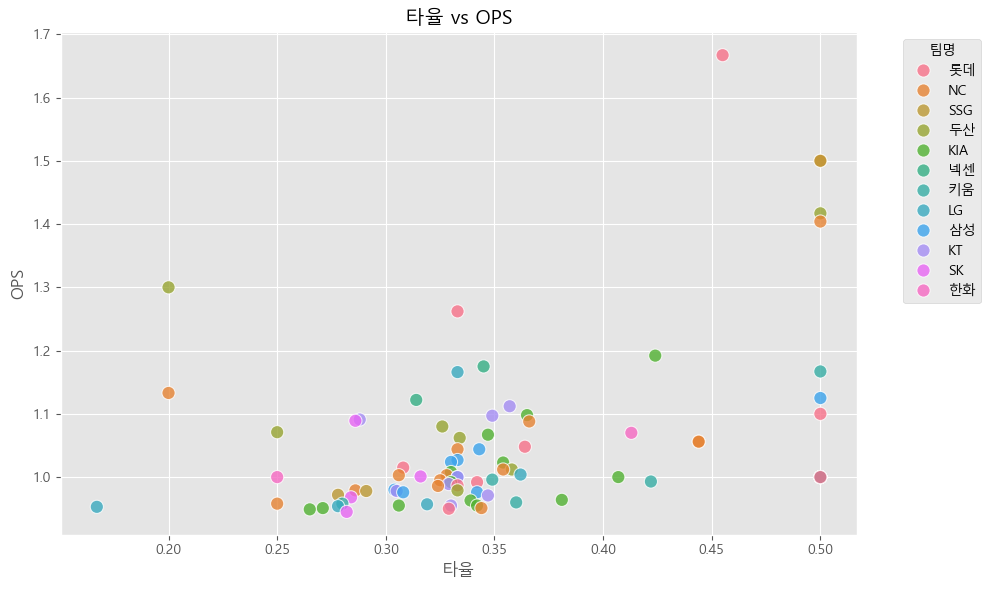

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔧 스타일 설정
plt.style.use('ggplot')  # ✅ ggplot 스타일
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 📂 경로 고정
base_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
file_hitter = f"{base_path}\\시즌별_타자_데이터.csv"

# 🔹 1. 데이터 불러오기
df_hitter = pd.read_csv(file_hitter, encoding='euc-kr')

# 🔹 2. OPS 계산
df_hitter["출루율"] = pd.to_numeric(df_hitter["출루율"], errors="coerce")
df_hitter["장타율"] = pd.to_numeric(df_hitter["장타율"], errors="coerce")
df_hitter["타율"] = pd.to_numeric(df_hitter["타율"], errors="coerce")
df_hitter["OPS"] = df_hitter["출루율"] + df_hitter["장타율"]

# 🔹 3. 유효한 행만 필터링
df_valid = df_hitter.dropna(subset=["타율", "OPS", "팀명", "선수명"])

# 🔹 4. OPS 상위 100명 추출
df_top = df_valid.sort_values("OPS", ascending=False).head(100)

# 🔹 5. 이상치 제거
df_top_filtered = df_top[(df_top["타율"] <= 0.6) & (df_top["OPS"] <= 2.0)]

# 🔹 6. 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_top_filtered,
    x="타율", y="OPS", hue="팀명",
    alpha=0.8, edgecolor='w', s=90
)

plt.title("타율 vs OPS", fontsize=14)
plt.xlabel("타율")
plt.ylabel("OPS")
plt.grid(True)
plt.legend(title="팀명", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 2. 포지션별 타율 / OPS

C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\72506820.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pos_mean.sort_values("타율", ascending=False),


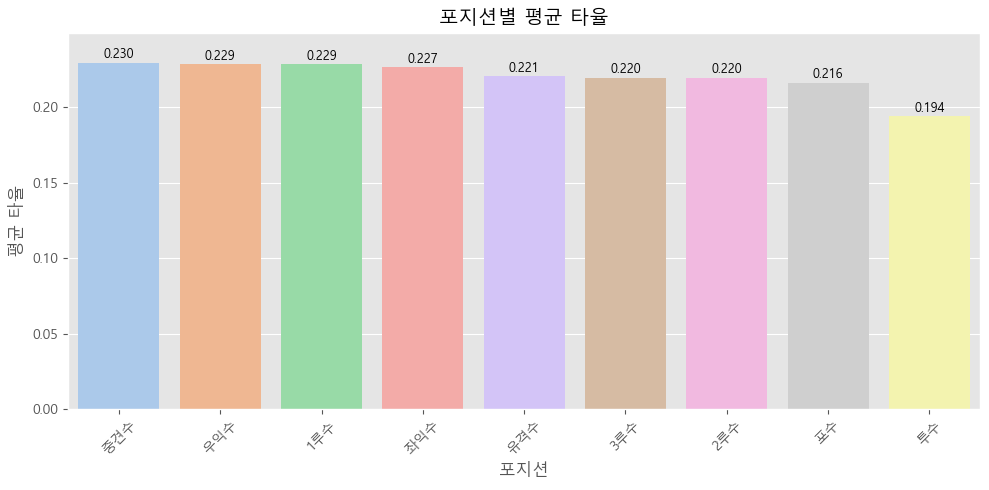

C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\72506820.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pos_mean.sort_values("OPS", ascending=False),


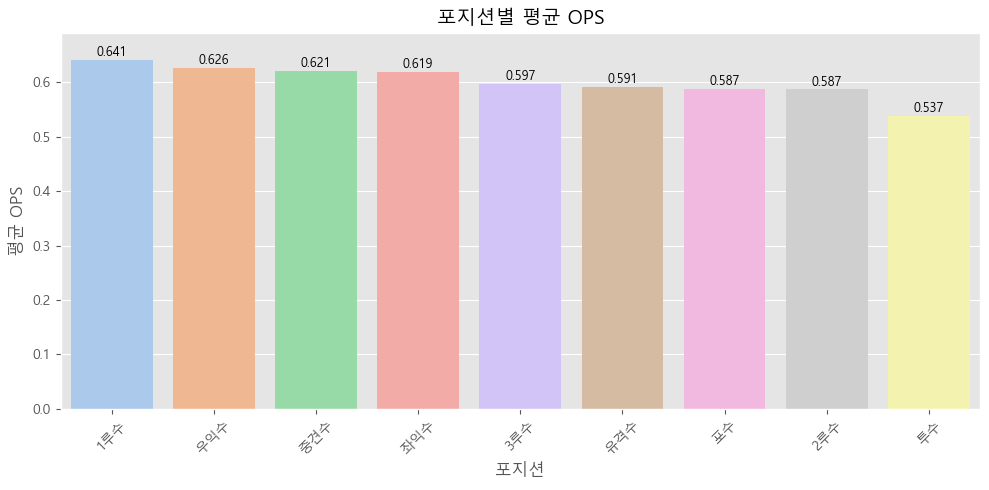

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 스타일 설정
plt.style.use('ggplot')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 📂 경로 고정
base_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
file_hitter = f"{base_path}\\시즌별_타자_데이터.csv"
file_defense = f"{base_path}\\시즌별_수비_데이터.csv"

# 🔹 1. 데이터 불러오기
df_hitter = pd.read_csv(file_hitter, encoding='euc-kr')
df_defense = pd.read_csv(file_defense, encoding='utf-8-sig')

# 🔹 2. OPS 계산
df_hitter["출루율"] = pd.to_numeric(df_hitter["출루율"], errors="coerce")
df_hitter["장타율"] = pd.to_numeric(df_hitter["장타율"], errors="coerce")
df_hitter["타율"] = pd.to_numeric(df_hitter["타율"], errors="coerce")
df_hitter["OPS"] = df_hitter["출루율"] + df_hitter["장타율"]

# 🔹 3. 유효한 열만 추출
df_hit = df_hitter[["선수명", "시즌", "타율", "OPS"]].dropna()
df_def = df_defense[["선수명", "시즌", "포지션"]].dropna()

# 🔹 4. 병합
df_merged = pd.merge(df_hit, df_def, on=["선수명", "시즌"])

# 🔹 5. 포지션별 평균 계산
df_pos_mean = df_merged.groupby("포지션")[["타율", "OPS"]].mean().reset_index()

# ✅ 6. 타율 그래프 (0부터 시작, 수치만 표시)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_pos_mean.sort_values("타율", ascending=False),
            x="포지션", y="타율", palette="pastel")

plt.title("포지션별 평균 타율", fontsize=14)
plt.xlabel("포지션")
plt.ylabel("평균 타율")
plt.xticks(rotation=45)
plt.ylim(0, df_pos_mean["타율"].max() + 0.02)  # y축 0부터 시작

for i, v in enumerate(df_pos_mean.sort_values("타율", ascending=False)["타율"]):
    plt.text(i, v + 0.003, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ✅ 7. OPS 그래프 (0부터 시작, 수치만 표시)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_pos_mean.sort_values("OPS", ascending=False),
            x="포지션", y="OPS", palette="pastel")

plt.title("포지션별 평균 OPS", fontsize=14)
plt.xlabel("포지션")
plt.ylabel("평균 OPS")
plt.xticks(rotation=45)
plt.ylim(0, df_pos_mean["OPS"].max() + 0.05)  # y축 0부터 시작

for i, v in enumerate(df_pos_mean.sort_values("OPS", ascending=False)["OPS"]):
    plt.text(i, v + 0.007, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 3. 팀별 상위 5인 OPS 평균 비교

C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\661771602.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top5.sort_values("상위5인_OPS_평균", ascending=False),


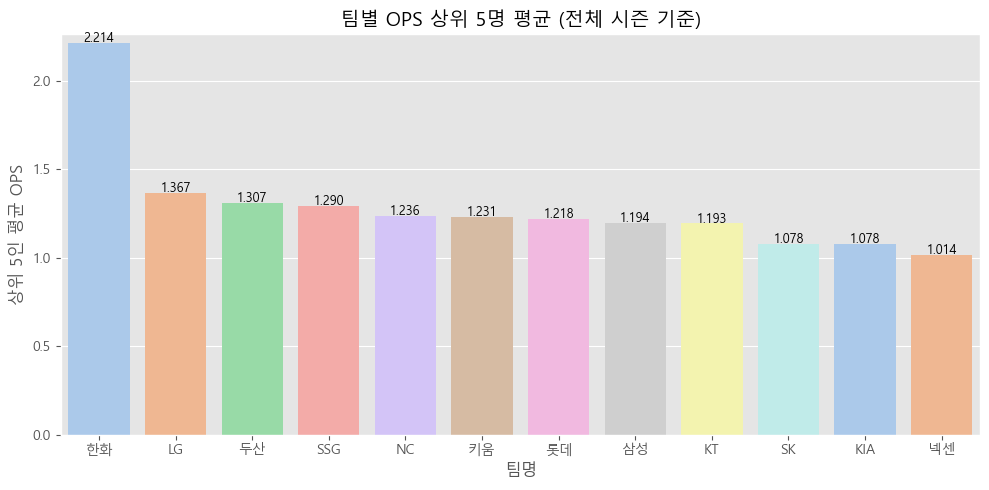

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 스타일 설정
plt.style.use('ggplot')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 📂 경로 고정
base_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
file_hitter = f"{base_path}\\시즌별_타자_데이터.csv"

# 🔹 1. 데이터 불러오기
df_hitter = pd.read_csv(file_hitter, encoding='euc-kr')

# 🔹 2. OPS 계산
df_hitter["출루율"] = pd.to_numeric(df_hitter["출루율"], errors="coerce")
df_hitter["장타율"] = pd.to_numeric(df_hitter["장타율"], errors="coerce")
df_hitter["OPS"] = df_hitter["출루율"] + df_hitter["장타율"]

# 🔹 3. 유효한 행만 추출
df_valid = df_hitter.dropna(subset=["팀명", "선수명", "OPS"])

# 🔹 4. 팀별 OPS 상위 5명 추출 후 평균 계산
df_top5 = (
    df_valid.sort_values(["팀명", "OPS"], ascending=[True, False])
    .groupby("팀명")
    .head(5)
    .groupby("팀명")["OPS"]
    .mean()
    .reset_index()
    .rename(columns={"OPS": "상위5인_OPS_평균"})
)

# 🔹 5. 시각화
plt.figure(figsize=(10, 5))
sns.barplot(data=df_top5.sort_values("상위5인_OPS_평균", ascending=False),
            x="팀명", y="상위5인_OPS_평균", palette="pastel")

plt.title("팀별 OPS 상위 5명 평균 (전체 시즌 기준)", fontsize=14)
plt.xlabel("팀명")
plt.ylabel("상위 5인 평균 OPS")
plt.ylim(0, df_top5["상위5인_OPS_평균"].max() + 0.05)

# ✅ 값 표시
for i, v in enumerate(df_top5.sort_values("상위5인_OPS_평균", ascending=False)["상위5인_OPS_평균"]):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\3193516871.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top5_2025.sort_values("상위5인_OPS_평균", ascending=False),


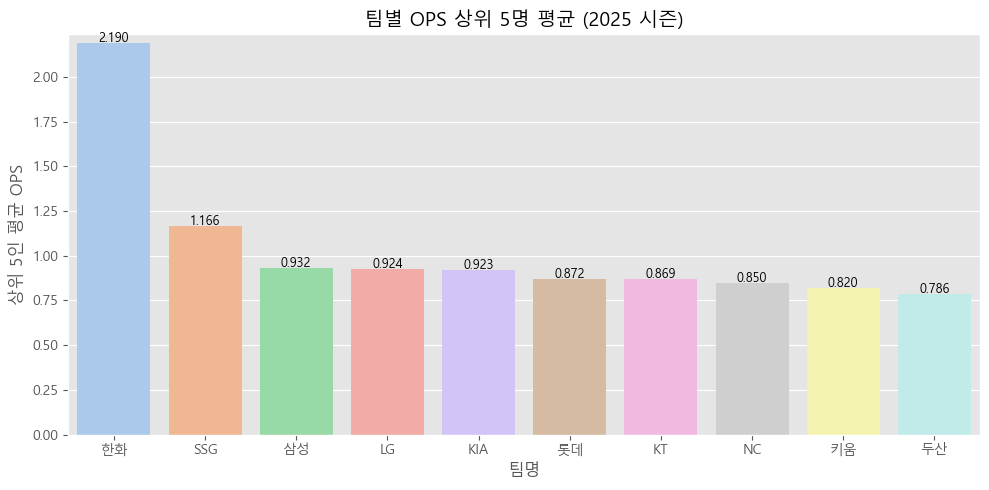

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 스타일 설정
plt.style.use('ggplot')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 📂 경로 고정
base_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
file_hitter = f"{base_path}\\시즌별_타자_데이터.csv"

# 🔹 1. 데이터 불러오기
df_hitter = pd.read_csv(file_hitter, encoding='euc-kr')

# 🔹 2. OPS 계산
df_hitter["출루율"] = pd.to_numeric(df_hitter["출루율"], errors="coerce")
df_hitter["장타율"] = pd.to_numeric(df_hitter["장타율"], errors="coerce")
df_hitter["OPS"] = df_hitter["출루율"] + df_hitter["장타율"]

# 🔹 3. 유효한 값 필터링 + 2025 시즌만 선택
df_2025 = df_hitter[df_hitter["시즌"] == 2025].dropna(subset=["팀명", "선수명", "OPS"])

# 🔹 4. 팀별 OPS 상위 5명 추출 후 평균 계산
df_top5_2025 = (
    df_2025.sort_values(["팀명", "OPS"], ascending=[True, False])
    .groupby("팀명")
    .head(5)
    .groupby("팀명")["OPS"]
    .mean()
    .reset_index()
    .rename(columns={"OPS": "상위5인_OPS_평균"})
)

# 🔹 5. 시각화
plt.figure(figsize=(10, 5))
sns.barplot(data=df_top5_2025.sort_values("상위5인_OPS_평균", ascending=False),
            x="팀명", y="상위5인_OPS_평균", palette="pastel")

plt.title("팀별 OPS 상위 5명 평균 (2025 시즌)", fontsize=14)
plt.xlabel("팀명")
plt.ylabel("상위 5인 평균 OPS")
plt.ylim(0, df_top5_2025["상위5인_OPS_평균"].max() + 0.05)

# ✅ 값 표시
for i, v in enumerate(df_top5_2025.sort_values("상위5인_OPS_평균", ascending=False)["상위5인_OPS_평균"]):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 4. ERA vs WHIP 산점도 + 회귀선

C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\579693823.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pitcher, x="시즌", y="평균자책점", palette="Spectral")


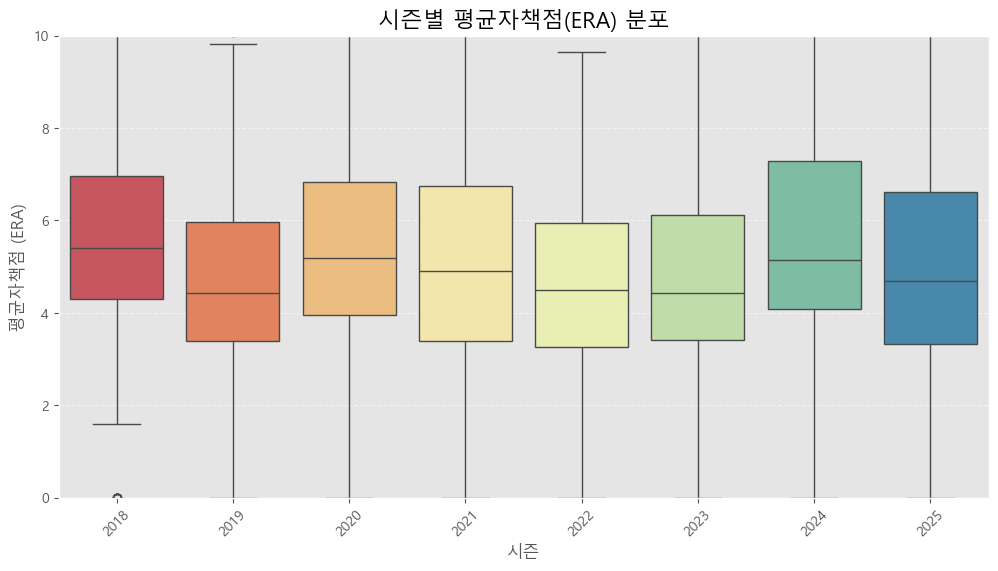

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ✅ CSV 로드
path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\시즌별_투수_데이터(변수 추가).csv"
df_pitcher = pd.read_csv(path, encoding="utf-8-sig")

# ✅ 타입 정리
df_pitcher["평균자책점"] = pd.to_numeric(df_pitcher["평균자책점"], errors="coerce")
df_pitcher["시즌"] = df_pitcher["시즌"].astype(str)

# ✅ 이상치 제거 (ERA > 20 제거)
df_pitcher = df_pitcher[df_pitcher["평균자책점"] <= 20]

# ✅ 시각화
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pitcher, x="시즌", y="평균자책점", palette="Spectral")
plt.title("시즌별 평균자책점(ERA) 분포", fontsize=16)
plt.xlabel("시즌", fontsize=12)
plt.ylabel("평균자책점 (ERA)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.ylim(0, 10)  # 보기 좋은 Y축 설정
plt.show()


### 5. 팀별 평균 QS 비율 / 9이닝당 삼진률 비교

C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\1863054695.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\1863054695.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\1863054695.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\1863054695.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\1863054695.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
C:\Users\THKIM\AppData\Local\Temp\ipykernel_2624\1863054695.py:35: FutureWarning: 

The `ci` parameter is deprecated. Us

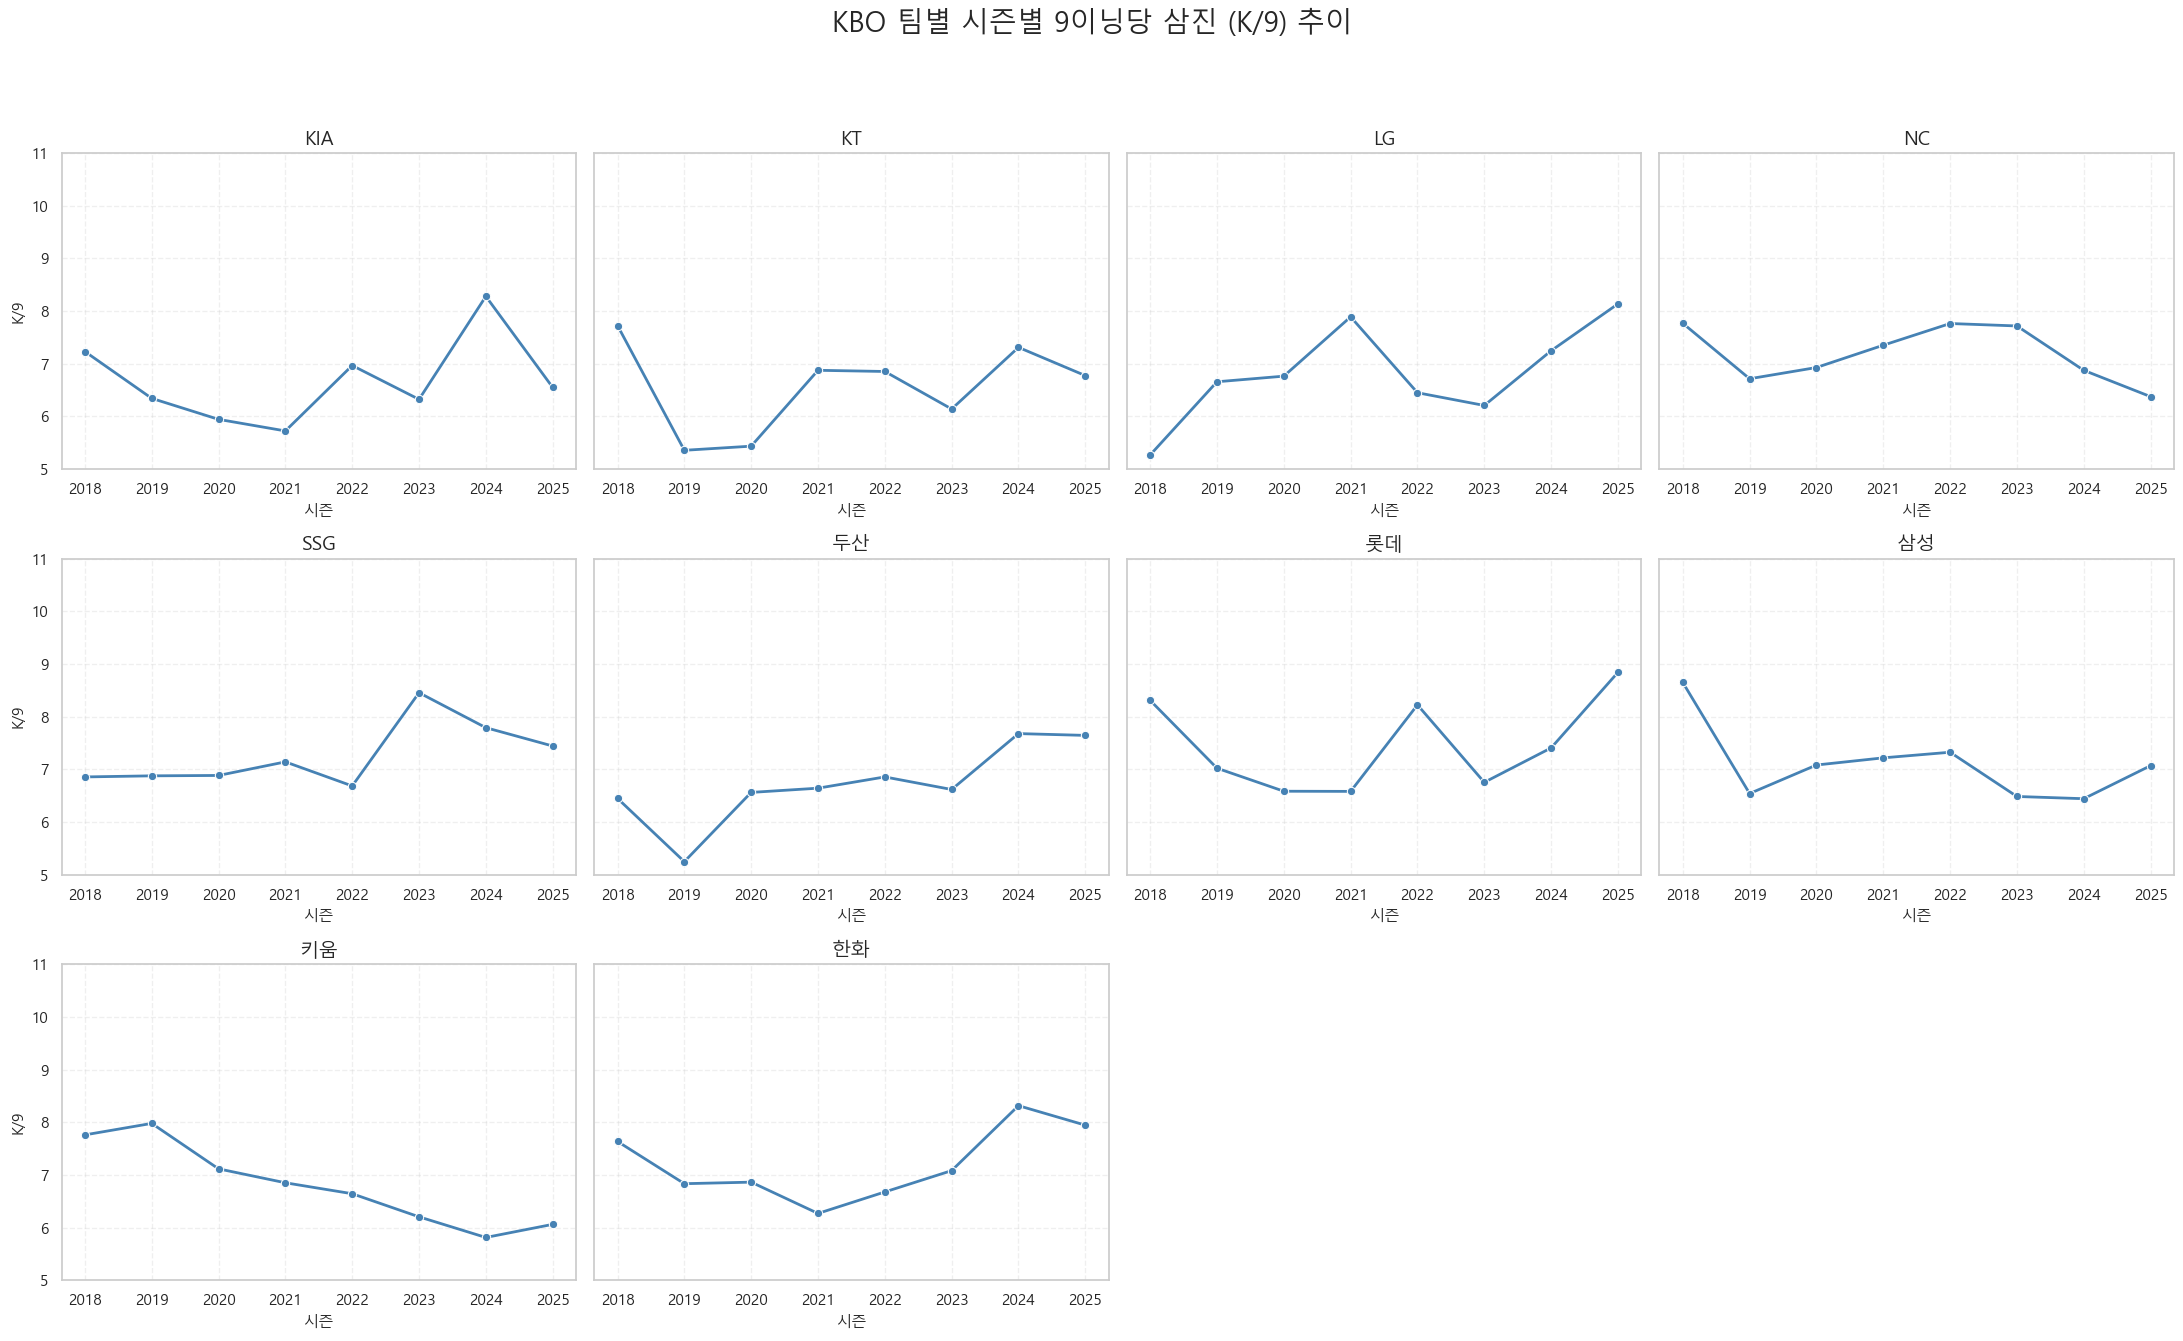

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import platform

# ✅ 한글 폰트 수동 지정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ✅ 데이터 로드
base_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
file_path = f"{base_path}\\시즌별_투수_데이터(변수 추가).csv"
df = pd.read_csv(file_path)

df['시즌'] = df['시즌'].astype(int)
df['9이닝당 삼진'] = pd.to_numeric(df['9이닝당 삼진'], errors='coerce')

# ✅ 팀명 통합
df['팀명'] = df['팀명'].replace({'SK': 'SSG', '넥센': '키움'})

# ✅ 10개 팀만 필터링
teams_10 = ['KIA', 'KT', 'LG', 'NC', 'SSG', '키움', '두산', '롯데', '삼성', '한화']
df = df[df['팀명'].isin(teams_10)]
teams = sorted(df['팀명'].unique())

# ✅ subplot 준비
fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharey=True)
axes = axes.flatten()

for i, team in enumerate(teams):
    ax = axes[i]
    team_data = df[df['팀명'] == team]

    sns.lineplot(
        data=team_data,
        x='시즌',
        y='9이닝당 삼진',
        marker='o',
        ax=ax,
        linewidth=2,
        color='steelblue',
        ci=None  # ✅ 파란 배경 제거
    )

    ax.set_title(team, fontsize=14)
    ax.set_xlabel("시즌", fontsize=11)
    ax.set_ylabel("K/9", fontsize=11)
    ax.set_ylim(5, 11)
    ax.grid(True, linestyle='--', alpha=0.3)

# ✅ 빈 subplot 제거
for j in range(len(teams), len(axes)):
    axes[j].axis("off")

plt.suptitle("KBO 팀별 시즌별 9이닝당 삼진 (K/9) 추이", fontsize=20, y=1.03)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


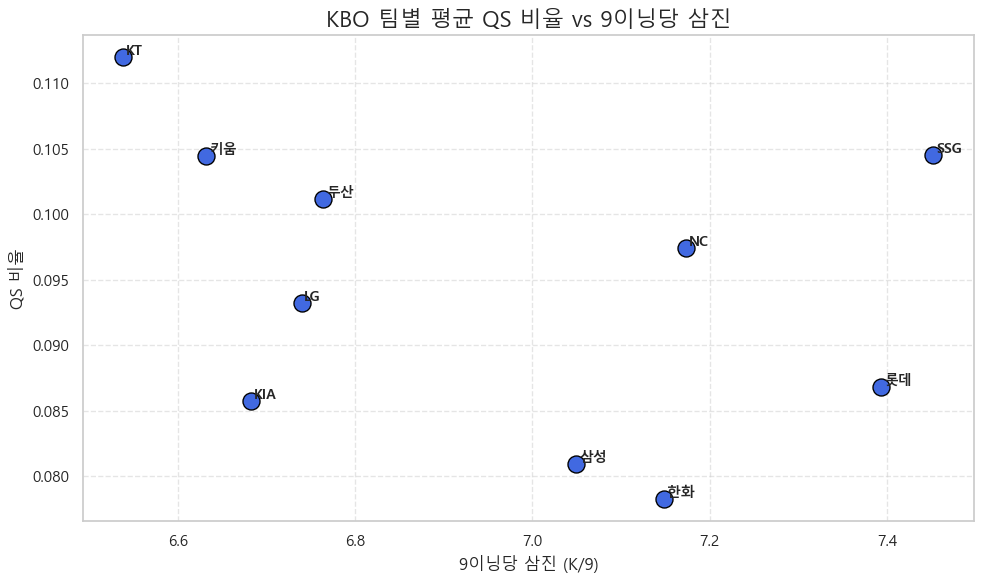

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from adjustText import adjust_text  # ✅ pip install adjustText

# ✅ 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

# ✅ 데이터 불러오기
base_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수"
file_path = f"{base_path}\\시즌별_투수_데이터(변수 추가).csv"
df = pd.read_csv(file_path)

# ✅ SK, 넥센 제외
exclude = ["SK", "넥센"]
df = df[~df["팀명"].isin(exclude)]

# ✅ 수치형 변환
df["퀄리티스타트"] = pd.to_numeric(df["퀄리티스타트"], errors="coerce")
df["선발"] = pd.to_numeric(df["선발"], errors="coerce")
df["9이닝당 삼진"] = pd.to_numeric(df["9이닝당 삼진"], errors="coerce")

# ✅ QS비율 계산
df["QS비율"] = df.apply(
    lambda row: row["퀄리티스타트"] / row["선발"] if row["선발"] > 0 else 0,
    axis=1
)

# ✅ 팀별 평균 계산
team_avg = df.groupby("팀명").agg({
    "QS비율": "mean",
    "9이닝당 삼진": "mean"
}).reset_index()

# ✅ 시각화
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=team_avg,
    x="9이닝당 삼진",
    y="QS비율",
    s=150,
    color="royalblue",
    edgecolor="black"
)

# ✅ 텍스트 조정용 리스트
texts = []
for i in range(len(team_avg)):
    texts.append(
        plt.text(
            team_avg["9이닝당 삼진"][i],
            team_avg["QS비율"][i],
            team_avg["팀명"][i],
            fontsize=10,
            weight='bold'
        )
    )

# ✅ 텍스트 자동 조정 (겹침 방지)
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

# ✅ 그래프 꾸미기
plt.title("KBO 팀별 평균 QS 비율 vs 9이닝당 삼진", fontsize=16)
plt.xlabel("9이닝당 삼진 (K/9)", fontsize=12)
plt.ylabel("QS 비율", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 6. 포지션별 실책수 & 수비율

In [66]:
pip install statannot

Note: you may need to restart the kernel to use updated packages.


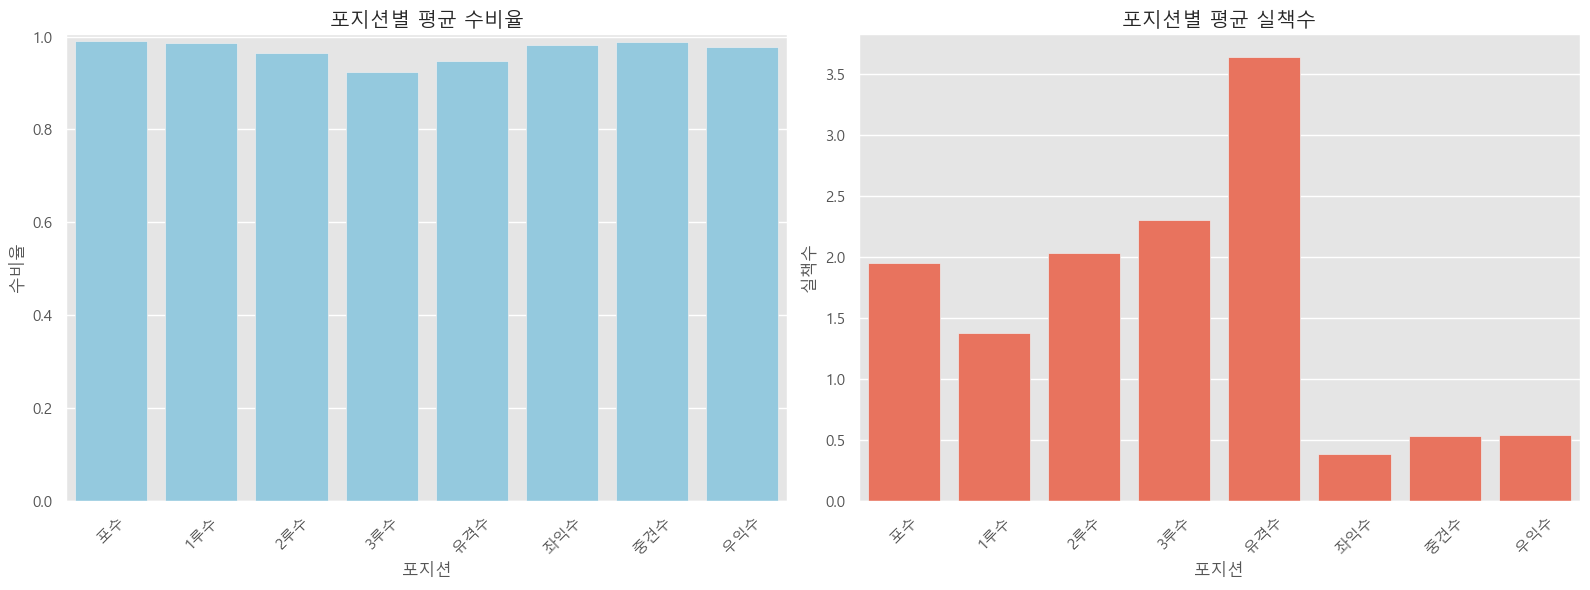

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')

# ✅ 데이터 경로
file_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\시즌별_수비_데이터.csv"

# ✅ 데이터 불러오기
df = pd.read_csv(file_path)

# ✅ 전처리
df.columns = df.columns.str.strip()
df.rename(columns={'실책': '실책수'}, inplace=True)
df['포지션'] = df['포지션'].astype(str).str.strip()
df['실책수'] = pd.to_numeric(df['실책수'], errors='coerce')
df['수비율'] = pd.to_numeric(df['수비율'], errors='coerce')
df = df[df['포지션'] != '지명타자']

# ✅ 포지션 순서 지정
position_order = ['포수', '1루수', '2루수', '3루수', '유격수', '좌익수', '중견수', '우익수']

# ✅ 그룹화
grouped = df.groupby('포지션', as_index=False)[['수비율', '실책수']].mean()

# ✅ 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 수비율 그래프 (단색)
sns.barplot(data=grouped, x='포지션', y='수비율', color='skyblue', order=position_order, ax=axes[0])
axes[0].set_title('포지션별 평균 수비율')
axes[0].set_ylabel('수비율')
axes[0].set_xlabel('포지션')
axes[0].set_ylim(0, 1.005)
axes[0].tick_params(axis='x', rotation=45)

# (2) 실책수 그래프 (단색)
sns.barplot(data=grouped, x='포지션', y='실책수', color='tomato', order=position_order, ax=axes[1])
axes[1].set_title('포지션별 평균 실책수')
axes[1].set_ylabel('실책수')
axes[1].set_xlabel('포지션')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 7. 도루성공률 vs 주루사

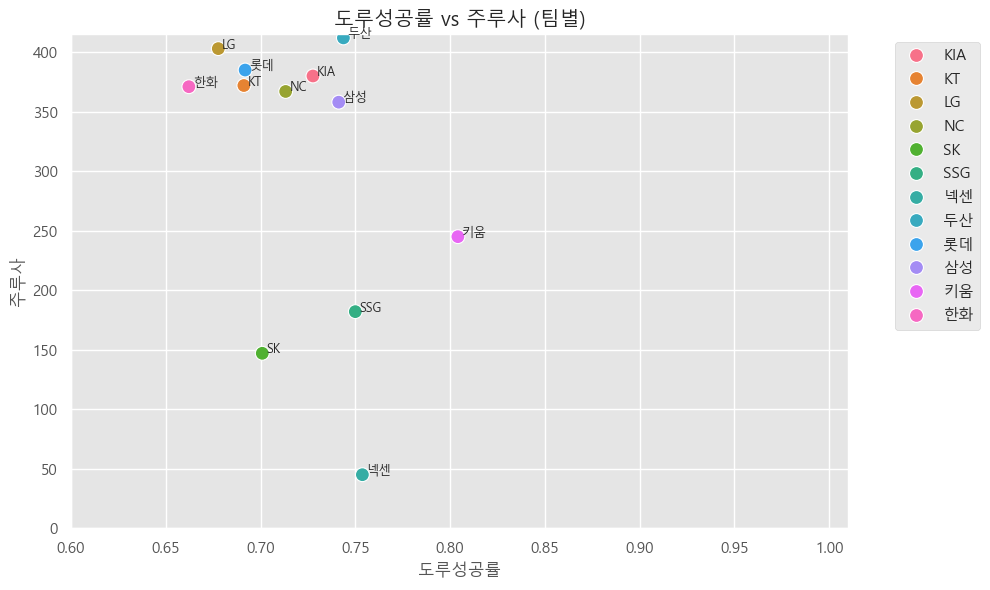

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')

# ✅ 데이터 불러오기
file_path = "C:/Users/THKIM/Desktop/3학년 여름방학 프로젝트/2025 KBO (한국프로야구) 오픈데이터 활용 공모전/data/변수/시즌별_주루_데이터.csv"
df = pd.read_csv(file_path)

# 컬럼 공백 제거
df.columns = df.columns.str.strip()

# ✅ 팀별 도루성공률과 주루사 평균 계산
team_df = df.groupby('팀명').agg({
    '도루성공': 'sum',
    '도루실패': 'sum',
    '주루사': 'sum'
}).reset_index()

# ✅ 도루성공률 계산
team_df['도루시도'] = team_df['도루성공'] + team_df['도루실패']
team_df['도루성공률'] = team_df['도루성공'] / team_df['도루시도']
team_df = team_df[team_df['도루시도'] > 0]  # 도루시도 0인 팀 제거

# ✅ 산점도 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(data=team_df, x='도루성공률', y='주루사', hue='팀명', s=100)

# ✅ 팀명 표시
for i in range(len(team_df)):
    plt.text(team_df['도루성공률'][i] + 0.002, team_df['주루사'][i], team_df['팀명'][i], fontsize=9)

plt.title('도루성공률 vs 주루사 (팀별)')
plt.xlabel('도루성공률')
plt.ylabel('주루사')
plt.xlim(0.6, 1.01)
plt.ylim(0, team_df['주루사'].max() + 3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 8. 시즌별 팀 평균 나이 vs 승률 변화

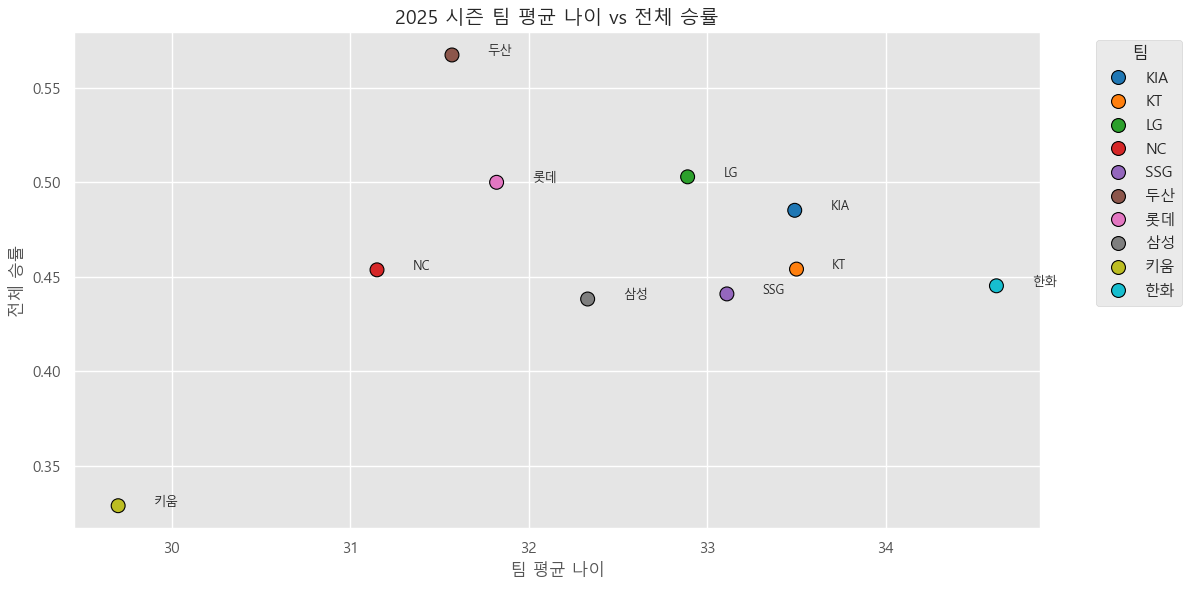

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')

# ✅ 파일 경로
file_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\변수_5_6번.csv"

# ✅ 데이터 불러오기
df = pd.read_csv(file_path)

# ✅ 2024~2025 시즌 필터링
df_filtered = df[df['시즌'].isin([2025])].copy()

# ✅ 승률 계산 (홈승률 + 원정승률) / 2
df_filtered['승률'] = (df_filtered['홈승률'] + df_filtered['원정승률']) / 2

# ✅ 팀별 평균 나이와 평균 승률 계산
df_grouped = df_filtered.groupby('팀')[['avg_age', '승률']].mean().reset_index()

# ✅ 시각화
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_grouped, x='avg_age', y='승률', hue='팀', palette='tab10', s=100, edgecolor='black')

# ✅ 팀 이름 라벨 추가
for i, row in df_grouped.iterrows():
    plt.text(row['avg_age'] + 0.2, row['승률'], row['팀'], fontsize=9)

plt.title('2025 시즌 팀 평균 나이 vs 전체 승률', fontsize=14)
plt.xlabel('팀 평균 나이')
plt.ylabel('전체 승률')
plt.legend(title='팀', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


###  9. 팀별 부상일수 vs 승률 관계 시각화

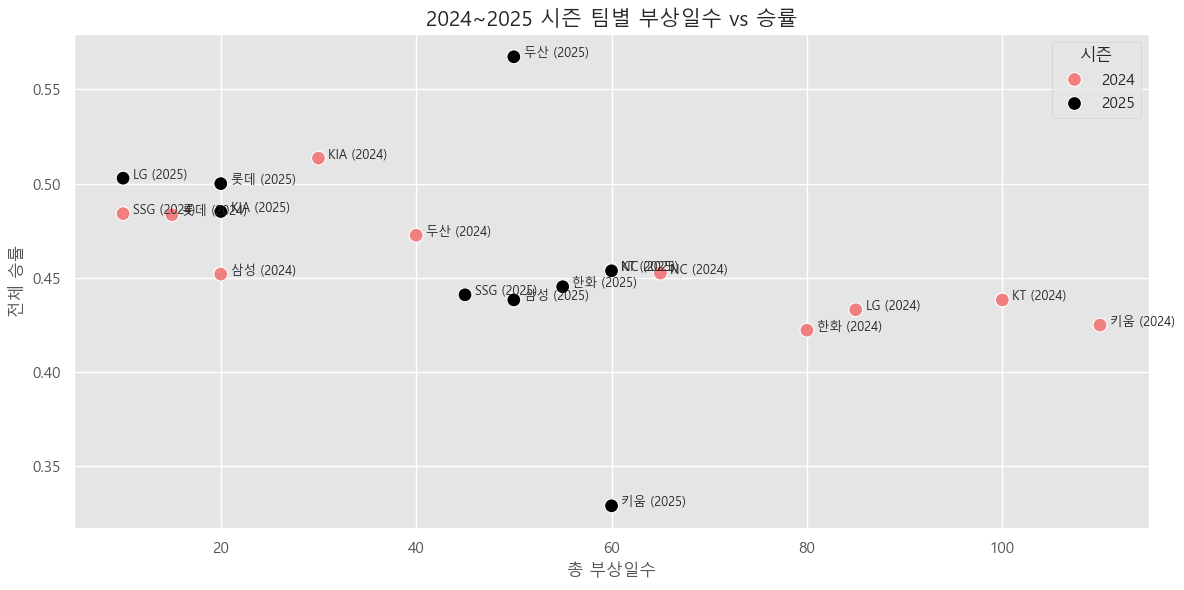

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 한글 폰트 설정 (윈도우용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')

# ✅ 데이터 로드
df = pd.read_csv(r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\변수_5_6번.csv")

# ✅ 2024~2025 시즌 필터링 + 승률 계산
df_filtered = df[df['시즌'].isin([2024, 2025])].copy()
df_filtered['승률'] = (df_filtered['홈승률'] + df_filtered['원정승률']) / 2

# ✅ 팀 + 시즌 중복 제거 (중복으로 점 여러 개 찍히는 문제 해결)
df_filtered = df_filtered.drop_duplicates(subset=['팀', '시즌'])

# ✅ 시각화
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_filtered,
    x='injury_days',
    y='승률',
    hue='시즌',
    palette={2024: 'lightcoral', 2025: 'black'},
    s=100
)

# ✅ 팀명 라벨 추가
for i in range(len(df_filtered)):
    team = df_filtered.iloc[i]
    plt.text(
        team['injury_days'] + 1,  # 살짝 오른쪽으로
        team['승률'],
        f"{team['팀']} ({team['시즌']})",
        fontsize=9
    )



# ✅ 제목 및 축
plt.title('2024~2025 시즌 팀별 부상일수 vs 승률', fontsize=15)
plt.xlabel('총 부상일수')
plt.ylabel('전체 승률')
plt.legend(title='시즌')
plt.tight_layout()
plt.show()


### 10. 팀별 WPA, RE24, HL_OPS

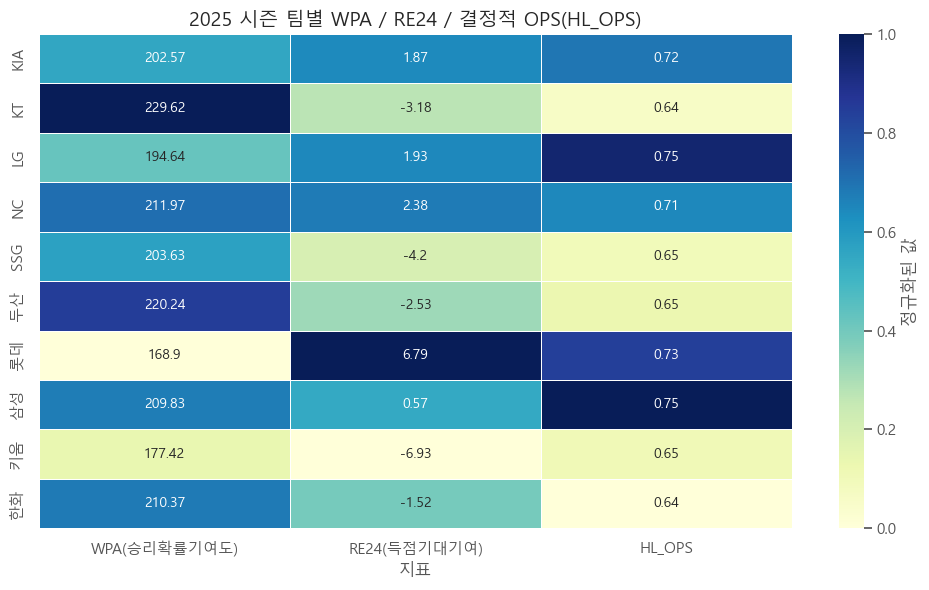

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ 데이터 불러오기
df = pd.read_csv(r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\변수_5_6번.csv")

# ✅ 2025 시즌만 필터링
df_2025 = df[df['시즌'] == 2025].copy()

# ✅ 팀별 평균값으로 중복 제거
df_2025_grouped = df_2025.groupby('팀')[['WPA(승리확률기여도)', 'RE24(득점기대기여)', 'HL_OPS']].mean()

# ✅ 정규화 (선택 사항)
heatmap_df_norm = (df_2025_grouped - df_2025_grouped.min()) / (df_2025_grouped.max() - df_2025_grouped.min())

# ✅ 히트맵 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df_norm,
    annot=df_2025_grouped.round(2),
    fmt='',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': '정규화된 값'}
)
plt.title('2025 시즌 팀별 WPA / RE24 / 결정적 OPS(HL_OPS)', fontsize=14)
plt.ylabel('')
plt.xlabel('지표')
plt.tight_layout()
plt.show()


### 11. 팀 특성 클러스터링 시각화

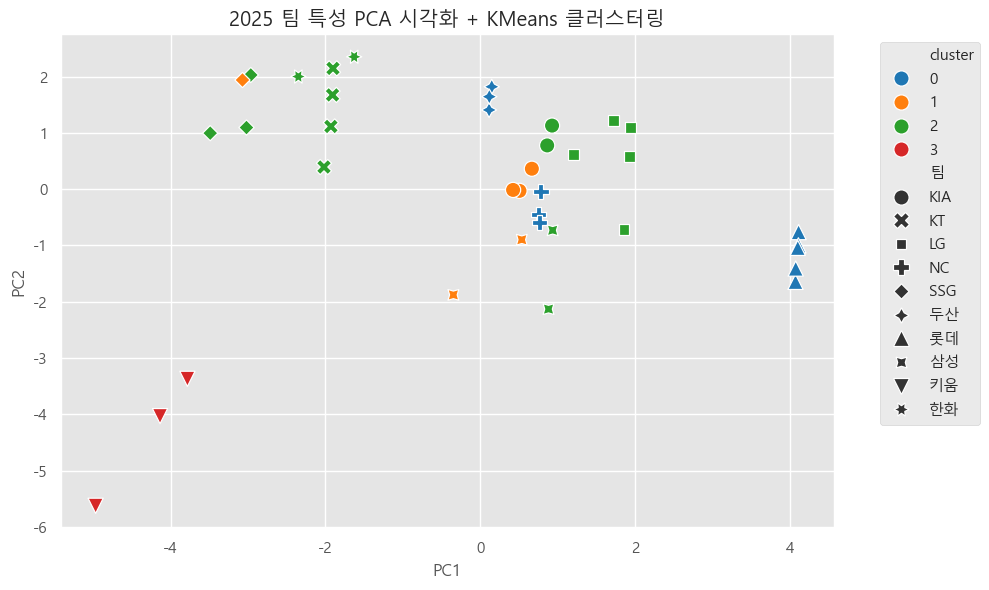

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ✅ 데이터 불러오기
team_path = r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\변수_5_6번.csv"
df_team = pd.read_csv(team_path)

# ✅ 사용할 변수 정의
cols = [
    '원정승률', '홈승률', '연속경기', '휴식일수', '구장OPS', '구장ERA', 'WPA(승리확률기여도)',
    'RE24(득점기대기여)', 'HL_WPA', 'HL_타율', 'HL_OPS', '상대승률',
    'injury_count', 'injury_days', 'rehab_count', 'rehab_days',
    'foreign_rehab_count', 'foreign_rehab_flag', 'avg_age'
]

# ✅ 2025 시즌 필터링
df = df_team[df_team['시즌'] == 2025].copy()
df = df.dropna(subset=cols)

# ✅ 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cols])

# ✅ PCA 차원 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ✅ KMeans 클러스터링 (k=4 예시)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# ✅ 결과 데이터프레임 구성
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['팀'] = df['팀'].values
df_pca['cluster'] = clusters

# ✅ 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', style='팀', palette='tab10', s=120)
plt.title('2025 팀 특성 PCA 시각화 + KMeans 클러스터링')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


| 클러스터   | 주요 팀           | 특징 요약               | 해석                 |
| ------ | -------------- | ------------------- | ------------------ |
| 2 (초록) | LG, KT, 한화  | 공격·수비 균형, HL·WPA 좋음 | **우승권 or 상위권 전력**  |
| 0 (파랑) | 롯데, KIA        | 수비나 일정 문제 있으나 전력 보유 | **중위권 가능성 팀**      |
| 1 (주황) | 두산, SSG        | 고령화·낮은 WPA·OPS      | **베테랑 중심의 중하위권 팀** |
| 3 (빨강) | 키움, 삼성         | 부상자 많음, 성적 부진       | **하위권 위험 팀**       |


###  12. 상관관계 히트맵 (구장OPS, 부상일수, WPA 등)

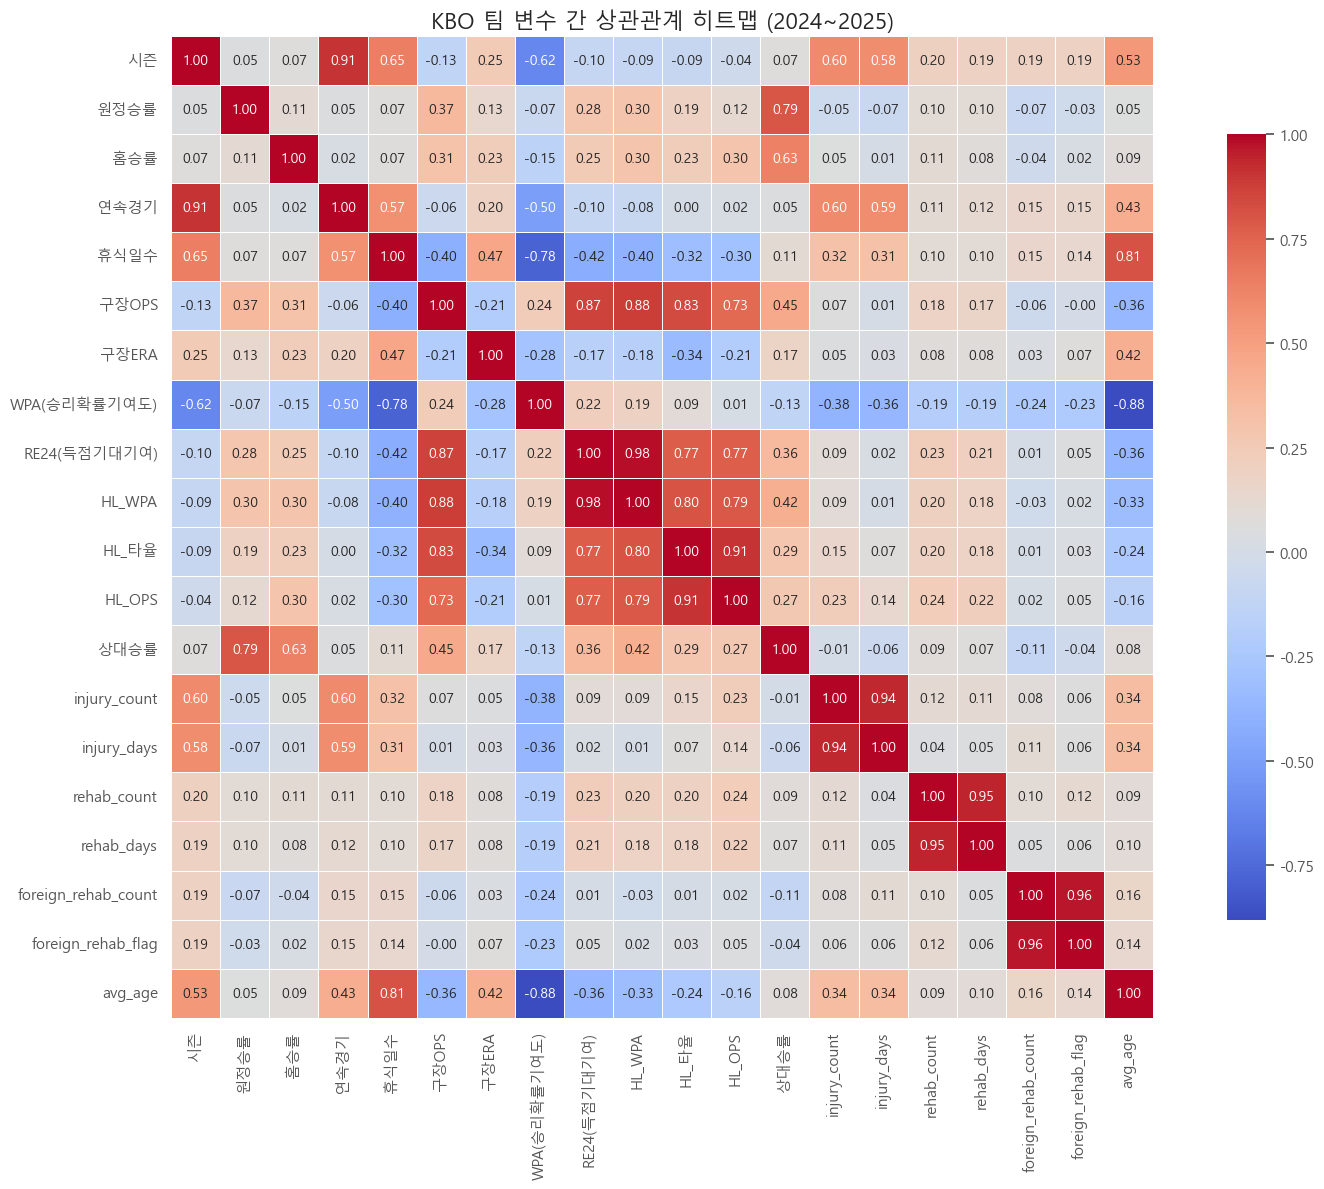

In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv(r"C:\Users\THKIM\Desktop\3학년 여름방학 프로젝트\2025 KBO (한국프로야구) 오픈데이터 활용 공모전\data\변수\변수_5_6번.csv")

# 2. 숫자형 변수만 필터링 (문자형 변수 제거)
numeric_cols = df.select_dtypes(include=['number'])

# 3. 상관계수 계산
corr_matrix = numeric_cols.corr()

# 4. 히트맵 시각화
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("KBO 팀 변수 간 상관관계 히트맵 (2024~2025)", fontsize=16)
plt.tight_layout()
plt.show()


1️⃣ 공격 기여 지표 간 높은 연관성
WPA(승리확률기여도) ↔ RE24(득점기대기여도): 0.98

WPA ↔ HL_OPS: 0.96, HL_타율: 0.92

RE24 ↔ HL_OPS: 0.97, HL_타율: 0.94

👉 결론: 고득점 상황에서의 공격 기여 지표는 서로 강하게 양의 상관관계
→ 공격력이 좋은 팀은 전반적으로 모든 지표에서 일관되게 높은 수치

2️⃣ 부상 관련 지표의 내부 연관성
injury_count ↔ injury_days: 0.96

injury_days ↔ rehab_days: 0.95

rehab_days ↔ foreign_rehab_count: 0.94

foreign_rehab_count ↔ foreign_rehab_flag: 1.00

👉 결론: 부상이 많으면 재활일수도 많고, 외국인 선수도 자주 재활에 포함
→ 부상 관련 지표들은 함께 움직이는 경향

3️⃣ 부상 ↔ 경기력 기여도 간의 음의 상관
WPA ↔ injury_days: –0.36

RE24 ↔ injury_days: –0.33

HL_OPS ↔ injury_days: –0.24

👉 결론: 부상일수가 많아질수록 경기력 지표는 낮아지는 경향
→ 건강한 팀일수록 WPA, RE24, HL_OPS가 높다

4️⃣ 평균 나이(avg_age)와 부상
avg_age ↔ injury_days: 0.66, rehab_days: 0.66

avg_age ↔ foreign_rehab_flag: 0.64

avg_age ↔ WPA: –0.62, RE24: –0.55

👉 결론: 평균 나이가 높을수록 부상과 재활이 많고, 경기력은 하락
→ 팀 고령화는 성적에 부정적 영향 가능성

5️⃣ 연속경기 ↔ 휴식일수: –0.78 (강한 음의 상관)
👉 많은 연속경기는 휴식 부족을 의미하며, 이는 부상 및 피로 누적과 연계 가능

### 모델 코드

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler

# =====================================
# 1. 데이터 로딩
# =====================================
df = pd.read_csv(r"C:\Users\yutt4\OneDrive\바탕 화면\kbo\모델_데이터.csv", encoding="utf-8")

# 2025 시즌 분리
df_2025 = df[df['시즌'] == 2025].copy()
df_past = df[df['시즌'] < 2025].copy()

# =====================================
# 2. 실제 2025 시즌 현재 성적 반영
# =====================================
actual_2025 = {
    "LG":   {"승":73, "패":44, "무":3},
    "한화": {"승":68, "패":48, "무":3},
    "SSG":  {"승":59, "패":55, "무":4},
    "롯데": {"승":60, "패":57, "무":5},
    "NC":   {"승":55, "패":54, "무":6},
    "KT":   {"승":59, "패":58, "무":4},
    "삼성": {"승":59, "패":59, "무":2},
    "KIA":  {"승":54, "패":59, "무":4},
    "두산": {"승":52, "패":63, "무":5},
    "키움": {"승":38, "패":80, "무":4},
}

for idx, row in df_2025.iterrows():
    team = row["팀명"]
    if team in actual_2025:
        df_2025.at[idx, "승"] = actual_2025[team]["승"]
        df_2025.at[idx, "패"] = actual_2025[team]["패"]
        df_2025.at[idx, "무"] = actual_2025[team]["무"]

# =====================================
# 3. 남은 경기 계산
# =====================================
df_2025["현재경기"] = df_2025["승"] + df_2025["무"] + df_2025["패"]
df_2025["남은경기"] = 144 - df_2025["현재경기"]

# =====================================
# 4. 훈련 데이터 (과거 시즌)
# =====================================
drop_cols = ["팀명", "순위", "승", "무", "패", "시즌"]
X_train = df_past.drop(columns=drop_cols)
y_train_win = df_past["승"]
y_train_draw = df_past["무"]

# =====================================
# 5. 테스트 데이터 (2025 시즌)
# =====================================
X_test = df_2025.drop(columns=drop_cols + ["현재경기", "남은경기"])

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================
# 6. Poisson 회귀 학습 (승, 무 모델)
# =====================================
model_win = PoissonRegressor(alpha=0.1, max_iter=1000)
model_win.fit(X_train_scaled, y_train_win)
pred_win_raw = model_win.predict(X_test_scaled)

model_draw = PoissonRegressor(alpha=0.1, max_iter=1000)
model_draw.fit(X_train_scaled, y_train_draw)
pred_draw_raw = model_draw.predict(X_test_scaled)

# =====================================
# 7. 남은 경기 비율 조정
# =====================================
pred_remain_win = np.round(pred_win_raw / 144 * df_2025["남은경기"])
pred_remain_draw = np.round(pred_draw_raw / 144 * df_2025["남은경기"])
pred_remain_lose = df_2025["남은경기"] - pred_remain_win - pred_remain_draw

# =====================================
# 8. 최종 합산
# =====================================
final_win = df_2025["승"].values + pred_remain_win
final_draw = df_2025["무"].values + pred_remain_draw
final_lose = df_2025["패"].values + pred_remain_lose

# =====================================
# 9. 결과 정리
# =====================================
result_df = pd.DataFrame({
    "팀명": df_2025["팀명"].values,
    "승": final_win.astype(int),
    "무": final_draw.astype(int),
    "패": final_lose.astype(int)
})

# 승률 & 순위
result_df["승률"] = (result_df["승"] + 0.5*result_df["무"]) / 144
result_df = result_df.sort_values(by=["승률","승"], ascending=[False,False]).reset_index(drop=True)
result_df["순위"] = result_df.index + 1

# =====================================
# 10. 출력 & 저장
# =====================================
print(result_df[["순위","팀명","승","무","패","승률"]])

save_cols = ["순위","팀명","승","무","패","승률"]
result_df.to_excel("2025_KBO_최종순위_예측.xlsx", index=False, columns=save_cols)

   순위   팀명   승  무   패        승률
0   1   LG  86  4  54  0.611111
1   2   한화  83  4  57  0.590278
2   3   롯데  71  6  67  0.513889
3   4  SSG  71  5  68  0.510417
4   5   삼성  71  2  71  0.500000
5   6   KT  70  4  70  0.500000
6   7   NC  68  7  69  0.496528
7   8  KIA  68  4  72  0.486111
8   9   두산  62  5  77  0.447917
9  10   키움  45  4  95  0.326389
